# EDA – Virtual Medical Warehouse

## 1. Dataset S1 – Healthcare Facilities
### Overview
### Data Quality
### Univariate Analysis
### Findings

## 2. Dataset S2 – Facility Inventory and Consumption
### Overview
### Data Quality
### Stock and Consumption Analysis
### Geographic Analysis
### Findings

## 3. Dataset S3 – General Supply Stock
### Overview
### Data Quality
### Quarterly Stock Analysis
### Findings

## 4. Dataset S5 – Demand and Allocation
### Overview
### Data Quality
### Demand and Allocation Analysis
### Findings

## 5. Overall Findings and Limitations

## Google Drive Setup

This notebook was originally created with local file paths.  
The cells below mount Google Drive and define the shared project folder so the notebook can run from Drive/Colab.

Project path:
`MyDrive/Madad for Medical Logistics/Dataset/Dryad_Dataset`


In [1]:
from google.colab import drive
drive.mount('/content/drive')

from pathlib import Path

BASE_PATH = Path(
    '/content/drive/MyDrive/Madad for Medical Logistics/Dataset/Dryad_Dataset'
)

FILES = {
    'S1': BASE_PATH / 'S1.csv',
    'S2': BASE_PATH / 'S2_Dhis2Data.csv',
    'S3': BASE_PATH / 'S3.csv',
    'S4': BASE_PATH / 'S4_AlternativeData.csv',
    'S5': BASE_PATH / 'S5_dfImp_popbased.csv',
}

for name, path in FILES.items():
    print(name, '->', path, '| exists:', path.exists())

ModuleNotFoundError: No module named 'google'

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
s1 = pd.read_csv(FILES['S1'])
s2 = pd.read_csv(FILES['S2'])
s3 = pd.read_csv(FILES['S3'])
s5 = pd.read_csv(FILES['S5'])

## Dataset S1 – Healthcare Facilities

In [ ]:
s1 = pd.read_csv(FILES['S1'])

display(s1.head())
print("Shape:", s1.shape)
print("Columns:", s1.columns.tolist())

s1.info()

,facility_type,hf_pk,district
0,CHC,0,Port Loko
1,CHP,1,Western Rural
2,MCHP,2,Western Rural
3,MCHP,3,Western Rural
4,CHP,4,Western Rural


Shape: (1280, 3)
Columns: ['facility_type', 'hf_pk', 'district']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1280 entries, 0 to 1279
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   facility_type  1280 non-null   object
 1   hf_pk          1280 non-null   int64 
 2   district       1280 non-null   object
dtypes: int64(1), object(2)
memory usage: 30.1+ KB


In [ ]:
print("Missing values:")
print(s1.isnull().sum())

print("\nDuplicated rows:", s1.duplicated().sum())
print("Duplicated facility IDs:", s1['hf_pk'].duplicated().sum())
print("Unique facility IDs:", s1['hf_pk'].nunique())

Missing values:
facility_type    0
hf_pk            0
district         0
dtype: int64

Duplicated rows: 0
Duplicated facility IDs: 0
Unique facility IDs: 1280


In [ ]:
print("Facility types:")
print(s1['facility_type'].value_counts())

print("\nNumber of districts:", s1['district'].nunique())
print(s1['district'].value_counts())

Facility types:
facility_type
MCHP        574
CHP         379
CHC         234
Clinic       47
Hospital     46
Name: count, dtype: int64

Number of districts: 16
district
Bo               134
Kenema           123
Moyamba          106
Tonkolili        104
Port Loko         92
Kono              87
Kailahun          86
Bombali           83
Pujehun           78
Kambia            70
Western Urban     67
Bonthe            59
Karene            55
Western Rural     55
Koinadugu         43
Falaba            38
Name: count, dtype: int64


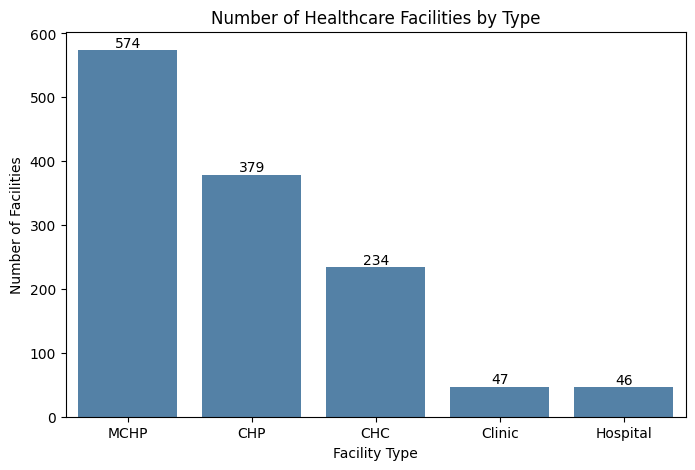

In [ ]:
facility_counts = (
    s1['facility_type']
    .value_counts()
    .reset_index()
)

facility_counts.columns = [
    'facility_type',
    'facility_count'
]

plt.figure(figsize=(8, 5))

ax = sns.barplot(
    data=facility_counts,
    x='facility_type',
    y='facility_count',
    color='steelblue'
)

ax.bar_label(ax.containers[0])

plt.title('Number of Healthcare Facilities by Type')
plt.xlabel('Facility Type')
plt.ylabel('Number of Facilities')
plt.show()

**Finding:** MCHP was the most common facility type with 574 facilities, while the dataset contained 46 hospitals. The hospital records will be particularly relevant to the virtual medical warehouse project.

In [ ]:
hospitals_s1 = s1[
    s1['facility_type'] == 'Hospital'
].copy()

all_districts = sorted(s1['district'].unique())

hospital_by_district = (
    hospitals_s1['district']
    .value_counts()
    .reindex(all_districts, fill_value=0)
    .rename_axis('district')
    .reset_index(name='hospital_count')
    .sort_values('hospital_count')
)

print("Number of hospitals:", len(hospitals_s1))

hospital_by_district

Number of hospitals: 46


,district,hospital_count
3,Falaba,0
1,Bombali,1
6,Karene,1
5,Kambia,1
9,Kono,1
12,Pujehun,1
8,Koinadugu,1
4,Kailahun,2
7,Kenema,2
2,Bonthe,3


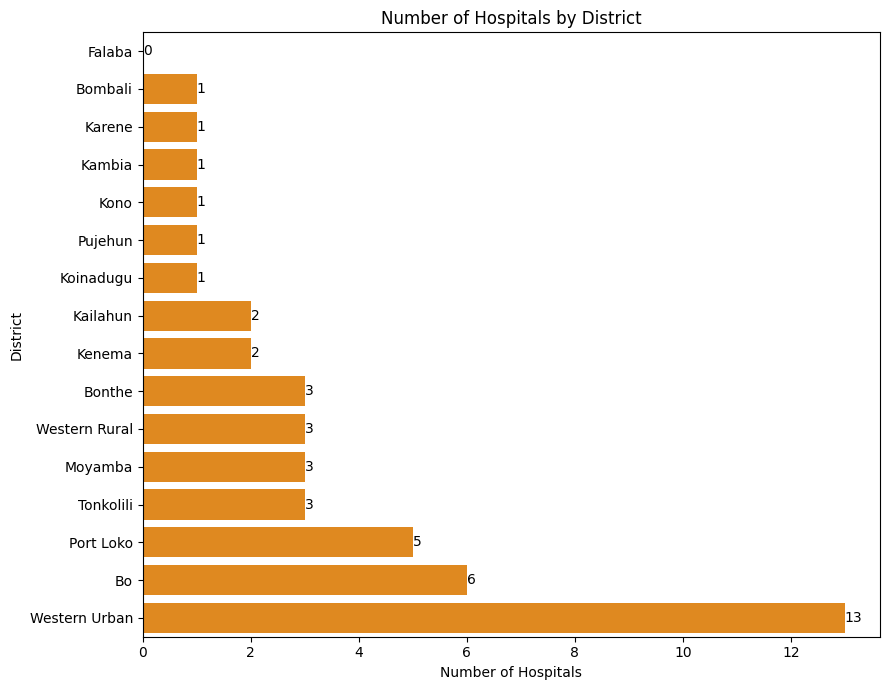

In [ ]:
plt.figure(figsize=(9, 7))

ax = sns.barplot(
    data=hospital_by_district,
    x='hospital_count',
    y='district',
    color='darkorange'
)

ax.bar_label(ax.containers[0])

plt.title('Number of Hospitals by District')
plt.xlabel('Number of Hospitals')
plt.ylabel('District')
plt.tight_layout()
plt.show()

**Finding:** The dataset contained 46 hospitals across 15 of the 16 districts. Western Urban had the highest number with 13 hospitals, while Falaba had no facility classified as a hospital.

## S1 EDA Summary

- S1 contained 1,280 healthcare facilities and 3 columns.
- No missing values, duplicated rows, or duplicated facility IDs were found.
- The dataset included five facility types across 16 districts.
- MCHP was the most common type with 574 facilities.
- The dataset contained 46 hospitals across 15 districts.
- Western Urban had the highest number of hospitals with 13, while Falaba had no facility classified as a hospital.
- S1 does not contain facility names, exact addresses, latitude, or longitude; therefore, it cannot independently calculate the nearest hospital.

**Facility codes:**
- CHC: Community Health Centre
- CHP: Community Health Post
- MCHP: Maternal and Child Health Post

## Dataset S2 – Facility Inventory and Consumption

In [ ]:
s2 = pd.read_csv(
    FILES['S2'],
    low_memory=False
)

display(s2.head())

print("Shape:", s2.shape)
print("Columns:", s2.columns.tolist())

s2.info()

,hf_pk,name1,date,stockout,received,consumption,closeBalance,openBalance,facility_type,lat,long,district,quarter,productID,normAvg,normStd
0,663,"Envelope, Dispensing, Plastic, 10cm x 7cm, Pcs",10/1/19,0,0,59,0,59,MCHP,9.089409,-12.00467,Bombali,2019Q4,1,152.030426,228.309369
1,667,"Envelope, Dispensing, Plastic, 10cm x 7cm, Pcs",10/1/19,0,0,70,0,70,CHP,8.903324,-12.04545,Bombali,2019Q4,1,152.030426,228.309369
2,745,"Envelope, Dispensing, Plastic, 10cm x 7cm, Pcs",10/1/19,1,0,14,0,14,CHP,8.807020,-12.08181,Bombali,2019Q4,1,152.030426,228.309369
3,753,"Envelope, Dispensing, Plastic, 10cm x 7cm, Pcs",10/1/19,0,0,100,0,100,CHP,8.791610,-12.06068,Bombali,2019Q4,1,152.030426,228.309369
4,725,"Envelope, Dispensing, Plastic, 10cm x 7cm, Pcs",10/1/19,0,0,100,0,100,MCHP,9.032880,-12.04858,Bombali,2019Q4,1,152.030426,228.309369


Shape: (457225, 16)
Columns: ['hf_pk', 'name1', 'date', 'stockout', 'received', 'consumption', 'closeBalance', 'openBalance', 'facility_type', 'lat', 'long', 'district', 'quarter', 'productID', 'normAvg', 'normStd']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 457225 entries, 0 to 457224
Data columns (total 16 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   hf_pk          457225 non-null  int64  
 1   name1          457225 non-null  object 
 2   date           457225 non-null  object 
 3   stockout       457225 non-null  int64  
 4   received       457225 non-null  int64  
 5   consumption    457225 non-null  int64  
 6   closeBalance   457225 non-null  int64  
 7   openBalance    457225 non-null  int64  
 8   facility_type  457225 non-null  object 
 9   lat            457225 non-null  float64
 10  long           457225 non-null  float64
 11  district       457225 non-null  object 
 12  quarter        457225 non-null  object

In [ ]:
s2_clean = s2.copy()

s2_clean['date'] = pd.to_datetime(
    s2_clean['date'],
    format='%m/%d/%y',
    errors='coerce'
)

In [ ]:
print("Missing values:")
print(s2_clean.isnull().sum())

print("\nDuplicated rows:", s2_clean.duplicated().sum())

print(
    "Duplicated facility-product-date records:",
    s2_clean.duplicated(
        subset=['hf_pk', 'productID', 'date']
    ).sum()
)

Missing values:
hf_pk            0
name1            0
date             0
stockout         0
received         0
consumption      0
closeBalance     0
openBalance      0
facility_type    0
lat              0
long             0
district         0
quarter          0
productID        0
normAvg          0
normStd          0
dtype: int64

Duplicated rows: 0
Duplicated facility-product-date records: 0


In [ ]:
print("Unique facilities:", s2_clean['hf_pk'].nunique())
print("Unique products:", s2_clean['productID'].nunique())
print("Unique districts:", s2_clean['district'].nunique())
print("Number of quarters:", s2_clean['quarter'].nunique())

print("Start date:", s2_clean['date'].min())
print("End date:", s2_clean['date'].max())

print("Stockout values:", sorted(s2_clean['stockout'].unique()))

Unique facilities: 1091
Unique products: 36
Unique districts: 16
Number of quarters: 16
Start date: 2019-10-01 00:00:00
End date: 2023-11-01 00:00:00
Stockout values: [np.int64(0), np.int64(1)]


In [ ]:
inventory_columns = [
    'received',
    'consumption',
    'openBalance',
    'closeBalance'
]

print("Negative values:")
print((s2_clean[inventory_columns] < 0).sum())

print("\nZero values:")
print((s2_clean[inventory_columns] == 0).sum())

stockout_count = s2_clean['stockout'].sum()
stockout_rate = s2_clean['stockout'].mean() * 100

print("\nStockout records:", stockout_count)
print(f"Overall stockout rate: {stockout_rate:.2f}%")

Negative values:
received        0
consumption     0
openBalance     0
closeBalance    0
dtype: int64

Zero values:
received        314526
consumption      53046
openBalance      78995
closeBalance     72053
dtype: int64

Stockout records: 61956
Overall stockout rate: 13.55%


**Finding:** No negative inventory values were found. The overall stockout rate was 13.55% (61,956 of 457,225 facility-product-date records). Zero values were retained because they may represent no receipts, no consumption, or depleted balances rather than missing data.

In [ ]:
inventory_summary = s2_clean[inventory_columns].describe().T

inventory_summary['zero_rate_pct'] = (
    (s2_clean[inventory_columns] == 0).mean() * 100
)

display(inventory_summary.round(2))

,count,mean,std,min,25%,50%,75%,max,zero_rate_pct
received,457225.0,162.02,663.50,0.0,0.0,0.0,50.0,100000.0,68.79
consumption,457225.0,161.03,378.27,0.0,10.0,50.0,173.0,48000.0,11.60
openBalance,457225.0,489.33,1840.77,0.0,10.0,100.0,480.0,282000.0,17.28
closeBalance,457225.0,492.71,1873.56,0.0,10.0,100.0,480.0,281880.0,15.76


**Finding:** Inventory variables were strongly right-skewed. Median quantities were substantially lower than their means and maximum values. Received quantities were zero in 68.79% of records, which may indicate periods with no deliveries. High-value observations were retained because they may represent valid differences between facilities and products.

,quarter,number_of_records,stockout_records,stockout_rate_pct
0,2019Q4,23157,979,4.23
1,2020Q1,23018,1036,4.50
2,2020Q2,25783,3191,12.38
3,2020Q3,28982,3637,12.55
4,2020Q4,37601,5229,13.91
5,2021Q1,31594,3804,12.04
6,2021Q2,33405,4656,13.94
7,2021Q3,24118,3654,15.15
8,2021Q4,25739,2821,10.96
9,2022Q1,23068,3868,16.77


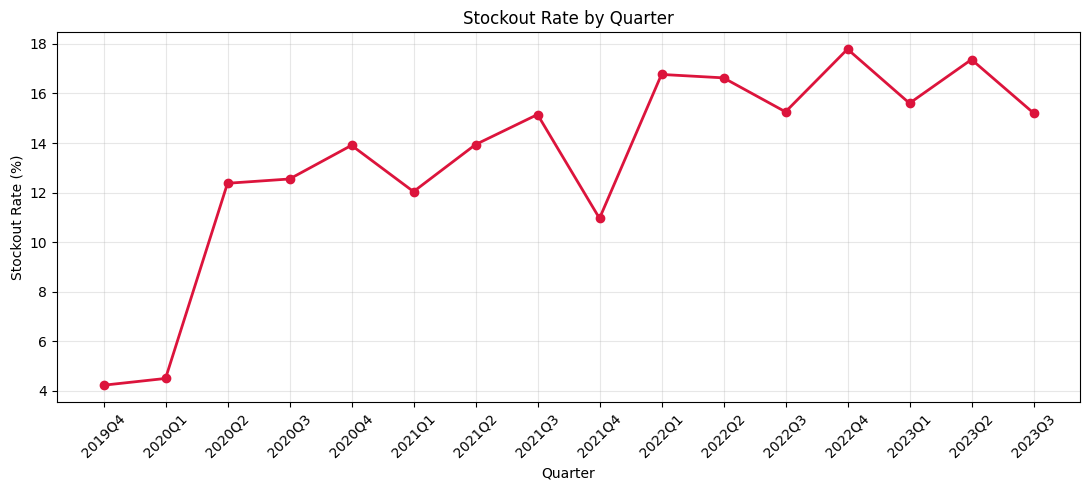

In [ ]:
quarter_stockout = (
    s2_clean.groupby('quarter')
    .agg(
        number_of_records=('stockout', 'size'),
        stockout_records=('stockout', 'sum'),
        stockout_rate_pct=('stockout', lambda x: x.mean() * 100)
    )
    .reset_index()
    .sort_values('quarter')
)

display(quarter_stockout.round(2))

plt.figure(figsize=(11, 5))

plt.plot(
    quarter_stockout['quarter'],
    quarter_stockout['stockout_rate_pct'],
    marker='o',
    linewidth=2,
    color='crimson'
)

plt.title('Stockout Rate by Quarter')
plt.xlabel('Quarter')
plt.ylabel('Stockout Rate (%)')
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Finding:** The stockout rate increased from 4.23% in 2019Q4 and reached its highest level of 17.79% in 2022Q4. It declined from 17.37% in 2023Q2 to 15.21% in 2023Q3 but remained substantially higher than at the beginning of the study period. Quarterly comparisons should be interpreted carefully because the number of records varied across quarters.

,productID,name1,number_of_records,facility_count,stockout_records,stockout_rate_pct
16,23,"Ciprofloxacin 500mg, Tab",2261,697,670,29.63
31,50,"Paracetamol (Acetaminophen) 500mg, Tab",23352,1091,6089,26.07
20,32,"Ampicillin 500mg, Pdr for IM/IV, Inj, Vial",20859,1087,5392,25.85
29,46,"Paracetamol (Acetaminophen) 250mg, Dispersible...",27810,1091,6736,24.22
28,44,"Glove, Exam, Latex, Medium, Nonsterile, Dispos...",18615,1089,4433,23.81
12,19,"Ferrous Sulphate 200mg, Tab",2298,634,522,22.72
14,21,"Neomycin & Bacitracin 0.5% & 500IU/g, Ointment...",681,316,150,22.03
9,16,"Aluminium Hydroxide 500mg, Tab",391,189,82,20.97
8,15,"Ceftriaxone 250mg, Pdr for Inj",562,172,112,19.93
13,20,"Water for Injection 10ml, Inj, Amp",12520,1067,2192,17.51


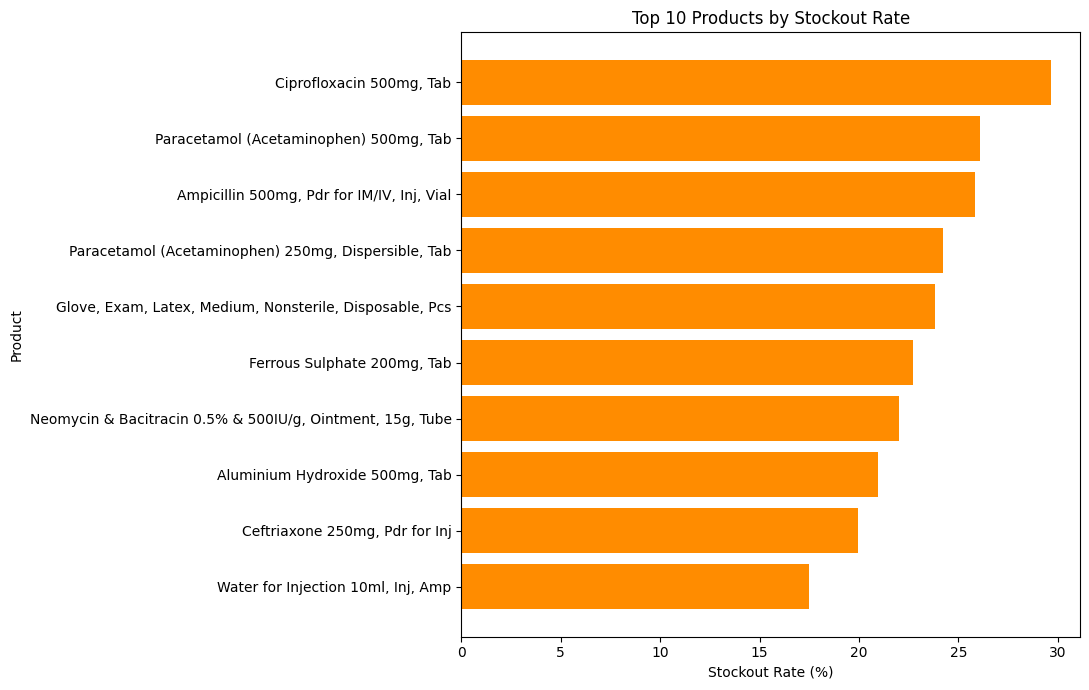

In [ ]:
product_stockout = (
    s2_clean.groupby(['productID', 'name1'])
    .agg(
        number_of_records=('stockout', 'size'),
        facility_count=('hf_pk', 'nunique'),
        stockout_records=('stockout', 'sum'),
        stockout_rate_pct=('stockout', lambda x: x.mean() * 100)
    )
    .reset_index()
    .sort_values('stockout_rate_pct', ascending=False)
)

top_products = product_stockout.head(10)

display(top_products.round(2))

plot_products = top_products.sort_values('stockout_rate_pct')

plt.figure(figsize=(11, 7))

plt.barh(
    plot_products['name1'],
    plot_products['stockout_rate_pct'],
    color='darkorange'
)

plt.title('Top 10 Products by Stockout Rate')
plt.xlabel('Stockout Rate (%)')
plt.ylabel('Product')
plt.tight_layout()
plt.show()

**Finding:** Ciprofloxacin 500mg had the highest stockout rate at 29.63%. However, Paracetamol 500mg recorded 6,089 stockout cases across all 1,091 facilities, indicating a more widely distributed supply issue. Stockout rates should therefore be interpreted together with the number of records and facility coverage.

,district,number_of_records,facility_count,stockout_records,stockout_rate_pct
9,Kono,21386,75,4168,19.49
14,Western Rural,12592,38,2301,18.27
15,Western Urban,10314,34,1731,16.78
1,Bombali,30239,73,4764,15.75
2,Bonthe,19427,50,3035,15.62
4,Kailahun,30977,72,4658,15.04
10,Moyamba,22653,90,3220,14.21
0,Bo,51899,115,7166,13.81
7,Kenema,52024,110,7136,13.72
11,Port Loko,38556,79,5165,13.40


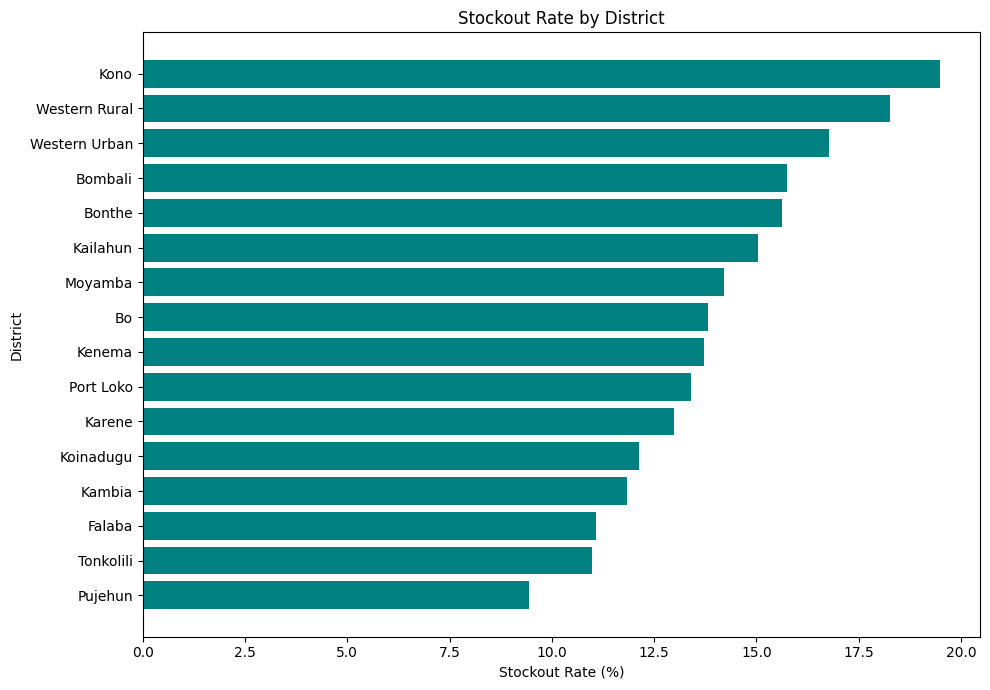

In [ ]:
district_stockout = (
    s2_clean.groupby('district')
    .agg(
        number_of_records=('stockout', 'size'),
        facility_count=('hf_pk', 'nunique'),
        stockout_records=('stockout', 'sum'),
        stockout_rate_pct=('stockout', lambda x: x.mean() * 100)
    )
    .reset_index()
    .sort_values('stockout_rate_pct', ascending=False)
)

display(district_stockout.round(2))

plot_districts = district_stockout.sort_values('stockout_rate_pct')

plt.figure(figsize=(10, 7))

plt.barh(
    plot_districts['district'],
    plot_districts['stockout_rate_pct'],
    color='teal'
)

plt.title('Stockout Rate by District')
plt.xlabel('Stockout Rate (%)')
plt.ylabel('District')
plt.tight_layout()
plt.show()

**Finding:** Kono had the highest stockout rate at 19.49%, followed by Western Rural at 18.27% and Western Urban at 16.78%. Although Bo and Kenema had lower rates, they recorded the largest absolute numbers of stockout cases. Therefore, both stockout rate and stockout volume should be considered when prioritizing regional supply needs.

In [ ]:
facility_type_summary = (
    s2_clean.groupby('facility_type')
    .agg(
        number_of_records=('stockout', 'size'),
        facility_count=('hf_pk', 'nunique'),
        stockout_records=('stockout', 'sum'),
        stockout_rate_pct=('stockout', lambda x: x.mean() * 100)
    )
    .reset_index()
)

display(facility_type_summary.round(2))

hospital_s2 = s2_clean[
    s2_clean['facility_type'] == 'Hospital'
].copy()

hospital_summary = (
    hospital_s2.groupby(['hf_pk', 'district', 'lat', 'long'])
    .agg(
        number_of_records=('stockout', 'size'),
        product_count=('productID', 'nunique'),
        stockout_records=('stockout', 'sum'),
        stockout_rate_pct=('stockout', lambda x: x.mean() * 100),
        median_close_balance=('closeBalance', 'median')
    )
    .reset_index()
    .sort_values('stockout_rate_pct', ascending=False)
)

print("Number of hospitals in S2:", hospital_s2['hf_pk'].nunique())
display(hospital_summary.round(2))

,facility_type,number_of_records,facility_count,stockout_records,stockout_rate_pct
0,CHC,101256,215,13273,13.11
1,CHP,138520,333,19765,14.27
2,Hospital,2017,5,61,3.02
3,MCHP,215432,538,28857,13.39


Number of hospitals in S2: 5


,hf_pk,district,lat,long,number_of_records,product_count,stockout_records,stockout_rate_pct,median_close_balance
2,71,Western Urban,8.47,-13.26,343,31,39,11.37,50.0
0,28,Western Urban,8.49,-13.29,193,20,4,2.07,30.0
3,638,Pujehun,7.35,-11.72,777,36,16,2.06,1750.0
1,47,Western Urban,8.46,-13.20,341,19,2,0.59,70.0
4,1047,Tonkolili,8.75,-11.84,363,36,0,0.00,1972.0


**Finding and Limitation:** S2 included inventory records for only 5 hospitals, compared with 46 hospitals identified in S1. Three hospitals were located in Western Urban, while Pujehun and Tonkolili each had one. Hospital 71 had the highest hospital-level stockout rate at 11.37%. Therefore, S2 can support a small hospital-transfer prototype, but it does not provide complete inventory coverage for all hospitals.

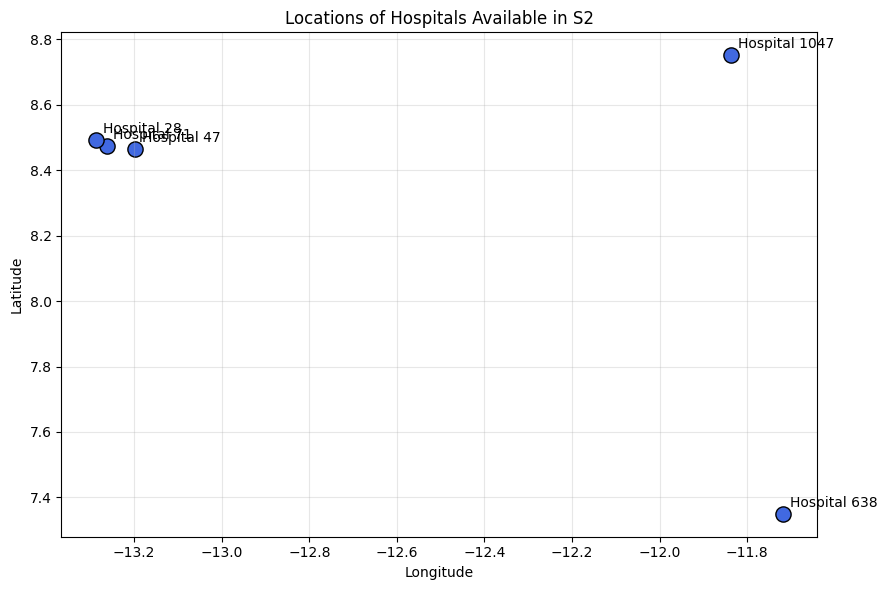

In [ ]:
hospital_locations = hospital_summary[
    ['hf_pk', 'district', 'lat', 'long']
].copy()

plt.figure(figsize=(9, 6))

plt.scatter(
    hospital_locations['long'],
    hospital_locations['lat'],
    s=120,
    color='royalblue',
    edgecolor='black'
)

for _, row in hospital_locations.iterrows():
    plt.annotate(
        f"Hospital {int(row['hf_pk'])}",
        (row['long'], row['lat']),
        xytext=(5, 5),
        textcoords='offset points'
    )

plt.title('Locations of Hospitals Available in S2')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Finding:** Hospitals 28, 47, and 71 formed a close geographic cluster in Western Urban, while hospitals 638 and 1047 were more geographically isolated. This demonstrates the importance of including distance when recommending a source hospital for emergency transfers.

In [ ]:
from math import radians, sin, cos, sqrt, atan2

def haversine_km(lat1, lon1, lat2, lon2):
    earth_radius = 6371  # kilometers

    lat1, lon1 = radians(lat1), radians(lon1)
    lat2, lon2 = radians(lat2), radians(lon2)

    difference_lat = lat2 - lat1
    difference_lon = lon2 - lon1

    a = (
        sin(difference_lat / 2) ** 2
        + cos(lat1) * cos(lat2)
        * sin(difference_lon / 2) ** 2
    )

    return earth_radius * 2 * atan2(sqrt(a), sqrt(1 - a))


hospital_pairs = []

for _, source in hospital_locations.iterrows():
    for _, target in hospital_locations.iterrows():

        if source['hf_pk'] != target['hf_pk']:
            distance = haversine_km(
                source['lat'],
                source['long'],
                target['lat'],
                target['long']
            )

            hospital_pairs.append({
                'source_hospital': int(source['hf_pk']),
                'source_district': source['district'],
                'nearest_hospital': int(target['hf_pk']),
                'nearest_district': target['district'],
                'distance_km': distance
            })


hospital_distances = pd.DataFrame(hospital_pairs)

nearest_hospitals = (
    hospital_distances
    .sort_values(['source_hospital', 'distance_km'])
    .groupby('source_hospital', as_index=False)
    .first()
)

display(nearest_hospitals.round(2))

,source_hospital,source_district,nearest_hospital,nearest_district,distance_km
0,28,Western Urban,71,Western Urban,3.48
1,47,Western Urban,71,Western Urban,7.14
2,71,Western Urban,28,Western Urban,3.48
3,638,Pujehun,1047,Tonkolili,156.31
4,1047,Tonkolili,47,Western Urban,153.06


**Finding:** Hospitals 28 and 71 were the closest pair, with an estimated straight-line distance of 3.48 km. Hospitals 638 and 1047 were geographically isolated, with their nearest available hospitals more than 150 km away. Distance can support transfer recommendations, but candidate hospitals must first be filtered by product availability and transferable surplus.

In [ ]:
zero_close_balance = s2_clean['closeBalance'].eq(0)

stockout_balance_check = pd.crosstab(
    s2_clean['stockout'].map({
        0: 'No stockout',
        1: 'Stockout'
    }),
    zero_close_balance.map({
        False: 'Closing balance > 0',
        True: 'Closing balance = 0'
    }),
    margins=True
)

display(stockout_balance_check)

stockout_with_zero_balance = (
    s2_clean.loc[
        s2_clean['stockout'] == 1,
        'closeBalance'
    ].eq(0).mean() * 100
)

zero_balance_flagged_stockout = (
    s2_clean.loc[
        s2_clean['closeBalance'] == 0,
        'stockout'
    ].mean() * 100
)

print(
    f"Stockout records with zero closing balance: "
    f"{stockout_with_zero_balance:.2f}%"
)

print(
    f"Zero closing-balance records flagged as stockout: "
    f"{zero_balance_flagged_stockout:.2f}%"
)

closeBalance,Closing balance = 0,Closing balance > 0,All
stockout,,,
No stockout,11337,383932,395269
Stockout,60716,1240,61956
All,72053,385172,457225


Stockout records with zero closing balance: 98.00%
Zero closing-balance records flagged as stockout: 84.27%


In [ ]:
# Hospital × Product historical coverage
hospital_s2 = s2_clean[
    s2_clean['facility_type'].eq('Hospital')
].copy()

hospital_s2['date'] = pd.to_datetime(
    hospital_s2['date'],
    errors='coerce'
)

hospital_product_history = (
    hospital_s2
    .groupby(
        ['hf_pk', 'productID', 'name1'],
        as_index=False
    )
    .agg(
        record_count=('date', 'size'),
        time_points=('date', 'nunique'),
        first_date=('date', 'min'),
        last_date=('date', 'max'),
        stockout_records=('stockout', 'sum')
    )
)

# Categorise the amount of historical data
hospital_product_history['history_band'] = pd.cut(
    hospital_product_history['time_points'],
    bins=[0, 5, 11, 23, float('inf')],
    labels=[
        'Fewer than 6 months',
        '6–11 months',
        '12–23 months',
        '24+ months'
    ]
)

print(
    "Hospital-product series:",
    len(hospital_product_history)
)

display(
    hospital_product_history['time_points']
    .describe()
    .to_frame('time_points')
    .round(2)
)

display(
    hospital_product_history['history_band']
    .value_counts(sort=False)
    .rename_axis('history_band')
    .reset_index(name='series_count')
)

display(
    hospital_product_history
    .sort_values(
        ['time_points', 'hf_pk'],
        ascending=[False, True]
    )
    .head(20)
)

Hospital-product series: 142


,time_points
count,142.00
mean,14.20
std,10.45
min,1.00
25%,5.00
50%,12.00
75%,23.00
max,41.00


,history_band,series_count
0,Fewer than 6 months,42
1,6–11 months,28
2,12–23 months,40
3,24+ months,32


,hf_pk,productID,name1,record_count,time_points,first_date,last_date,stockout_records,history_band
94,638,38,"Albendazole 400mg, Tab",41,41,2019-10-01,2023-11-01,0,24+ months
90,638,32,"Ampicillin 500mg, Pdr for IM/IV, Inj, Vial",37,37,2019-10-01,2023-11-01,0,24+ months
97,638,43,"Zinc Sulphate 20mg, Dispersible, Tab",37,37,2019-10-01,2023-11-01,0,24+ months
28,47,38,"Albendazole 400mg, Tab",36,36,2019-10-01,2023-04-01,0,24+ months
31,47,43,"Zinc Sulphate 20mg, Dispersible, Tab",35,35,2019-11-01,2023-10-01,0,24+ months
95,638,39,"Oral Rehydration Salts (ORS), Sachet",34,34,2019-10-01,2023-10-01,0,24+ months
96,638,42,"Methyldopa 250mg, Tab",34,34,2019-10-01,2023-08-01,0,24+ months
92,638,34,"Folic Acid 5mg, Tab",33,33,2019-10-01,2023-08-01,0,24+ months
93,638,35,"Oxytocin 10IU, Inj, Amp",33,33,2019-10-01,2023-11-01,0,24+ months
29,47,39,"Oral Rehydration Salts (ORS), Sachet",32,32,2019-10-01,2023-10-01,0,24+ months


**Preliminary finding:** Historical coverage varied substantially across hospital-product series. Half of the series contained no more than 12 monthly observations, while only 32 series contained at least 24 observations. The continuity of these observations must be examined before assessing forecasting feasibility.

In [ ]:
def longest_consecutive_months(date_series):
    month_numbers = np.sort(
        date_series
        .dt.to_period('M')
        .astype('int64')
        .unique()
    )

    if len(month_numbers) == 0:
        return 0

    break_positions = (
        np.where(np.diff(month_numbers) != 1)[0] + 1
    )

    consecutive_runs = np.split(
        month_numbers,
        break_positions
    )

    return max(len(run) for run in consecutive_runs)


consecutive_history = (
    hospital_s2
    .groupby(['hf_pk', 'productID', 'name1'])['date']
    .apply(longest_consecutive_months)
    .reset_index(name='longest_consecutive_run')
)

history_gap_check = (
    hospital_product_history
    .merge(
        consecutive_history,
        on=['hf_pk', 'productID', 'name1'],
        how='left'
    )
)

# Number of calendar months between the first and last observations
history_gap_check['expected_months'] = (
    (history_gap_check['last_date'].dt.year -
     history_gap_check['first_date'].dt.year) * 12
    +
    (history_gap_check['last_date'].dt.month -
     history_gap_check['first_date'].dt.month)
    + 1
)

history_gap_check['coverage_pct'] = (
    history_gap_check['time_points']
    / history_gap_check['expected_months']
    * 100
).round(2)

display(
    history_gap_check[
        [
            'time_points',
            'expected_months',
            'coverage_pct',
            'longest_consecutive_run'
        ]
    ].describe().round(2)
)

consecutive_thresholds = pd.DataFrame({
    'minimum_consecutive_months': [6, 12, 18, 24],
    'series_count': [
        (history_gap_check['longest_consecutive_run'] >= 6).sum(),
        (history_gap_check['longest_consecutive_run'] >= 12).sum(),
        (history_gap_check['longest_consecutive_run'] >= 18).sum(),
        (history_gap_check['longest_consecutive_run'] >= 24).sum()
    ]
})

display(consecutive_thresholds)

display(
    history_gap_check
    .sort_values(
        'longest_consecutive_run',
        ascending=False
    )
    .head(20)
)

,time_points,expected_months,coverage_pct,longest_consecutive_run
count,142.00,142.00,142.00,142.00
mean,14.20,33.03,50.43,6.32
std,10.45,17.59,26.54,5.87
min,1.00,1.00,5.41,1.00
25%,5.00,15.00,28.78,2.00
50%,12.00,41.50,47.60,4.00
75%,23.00,47.00,64.96,8.00
max,41.00,50.00,100.00,22.00


,minimum_consecutive_months,series_count
0,6,53
1,12,29
2,18,12
3,24,0


,hf_pk,productID,name1,record_count,time_points,first_date,last_date,stockout_records,history_band,longest_consecutive_run,expected_months,coverage_pct
80,638,17,"Metoclopramide HCl 10mg, Tab",28,28,2019-10-01,2023-06-01,1,24+ months,22,45,62.22
94,638,38,"Albendazole 400mg, Tab",41,41,2019-10-01,2023-11-01,0,24+ months,22,50,82.00
97,638,43,"Zinc Sulphate 20mg, Dispersible, Tab",37,37,2019-10-01,2023-11-01,0,24+ months,22,50,74.00
96,638,42,"Methyldopa 250mg, Tab",34,34,2019-10-01,2023-08-01,0,24+ months,22,47,72.34
95,638,39,"Oral Rehydration Salts (ORS), Sachet",34,34,2019-10-01,2023-10-01,0,24+ months,22,49,69.39
75,638,6,"Cannula, IV, 18G, Short, Sterile, Disposable, Pcs",26,26,2019-10-01,2023-04-01,3,24+ months,22,43,60.47
92,638,34,"Folic Acid 5mg, Tab",33,33,2019-10-01,2023-08-01,0,24+ months,22,47,70.21
72,638,3,"Syringe, Luer, 10ml, Disposable, Pcs",25,25,2019-11-01,2023-03-01,1,24+ months,21,41,60.98
85,638,22,"Salbutamol 100mcg/dose, Aerosol, Inhaler",25,25,2019-12-01,2023-08-01,0,24+ months,20,45,55.56
27,47,35,"Oxytocin 10IU, Inj, Amp",23,23,2019-10-01,2023-04-01,0,12–23 months,19,43,53.49


### Hospital-Product Forecasting Feasibility

The hospital subset contained 142 hospital-product time series. Although the median series contained 12 observations, the median temporal coverage was only 47.60%, and the median longest consecutive sequence was four months.

Only 29 series contained at least 12 consecutive months, 12 contained at least 18 consecutive months, and none contained 24 consecutive months. Therefore, the available hospital-level history is insufficient for developing reliable independent forecasting models for every hospital-product pair.

A pooled global model that learns from all available facility-product records is more appropriate. Alternatively, forecasting may be limited to the small subset of series with sufficient consecutive history. This limitation should be considered when interpreting predictions for hospitals.

## S2 EDA Summary

### Dataset Overview

- S2 contains 457,225 facility-product-date records and 16 columns.
- It covers 1,091 healthcare facilities, 36 products, 16 districts, and 16 quarters.
- The recorded period extends from October 2019 to November 2023.
- No missing values, duplicated records, or negative inventory quantities were identified.
- Inventory variables were strongly right-skewed, so high values were retained and interpreted cautiously.

### Main Findings

- The overall stockout rate was 13.55%, representing 61,956 records.
- Approximately 98.00% of stockout records had a zero closing balance.
- However, only 84.27% of zero closing-balance records were flagged as stockouts, showing that the two indicators are strongly related but not identical.
- The highest quarterly stockout rate was 17.79% in 2022Q4.
- The rate decreased from 17.37% in 2023Q2 to 15.21% in 2023Q3 but remained higher than at the beginning of the study period.
- Ciprofloxacin 500mg had the highest product stockout rate at 29.63%.
- Paracetamol 500mg recorded 6,089 stockout cases across all 1,091 facilities, indicating a widespread supply issue.
- Kono had the highest district-level stockout rate at 19.49%, followed by Western Rural at 18.27%.
- S2 included inventory data for only 5 hospitals. Hospital 71 had the highest hospital-level stockout rate at 11.37%.
- Hospitals 28 and 71 were the closest pair, with an estimated straight-line distance of 3.48 km.

### Relevance to the Virtual Medical Warehouse

- S2 supports facility-level inventory, consumption, receipt, stockout, and geographic analyses.
- Its coordinates can support identifying the nearest facility during an emergency.
- Product availability and transferable surplus must be checked before selecting the nearest source hospital.

### Limitations

- Only 5 of the 46 hospitals identified in S1 had inventory records in S2.
- The dataset does not contain expiry dates, batch numbers, or explicit safety-stock thresholds.
- Therefore, expired products and transferable surplus cannot be identified directly.
- Quarterly record coverage varied, which may affect comparisons over time.
- Calculated distances are straight-line estimates and do not represent road travel time.

## 3. Dataset S3 – General Supply Stock


In [ ]:
s3 = pd.read_csv(FILES['S3'])

s3.head()

,Item,Stock,Quarter
0,"(Syringe, AutoDestruct, SoloShot)",0,2023Q1
1,"(Syringe, AutoDestruct, SoloShot)",219034,2022Q4
2,"Acetazolamide 250mg, Tab",14059,2023Q2
3,"Albendazole 400mg, Tab",2767594,2023Q1
4,"Albendazole 400mg, Tab",1860527,2023Q2


In [ ]:
print("Shape:", s3.shape)
print("Columns:", s3.columns.tolist())

s3.info()

Shape: (341, 3)
Columns: ['Item', 'Stock', 'Quarter']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 341 entries, 0 to 340
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   Item     341 non-null    object
 1   Stock    341 non-null    int64 
 2   Quarter  341 non-null    object
dtypes: int64(1), object(2)
memory usage: 8.1+ KB


In [ ]:
Shape: (341, 3)
Columns: ['Item', 'Stock', 'Quarter']

In [ ]:
print("Missing values:")
print(s3.isnull().sum())

print("\nDuplicated rows:", s3.duplicated().sum())

Missing values:
Item       0
Stock      0
Quarter    0
dtype: int64

Duplicated rows: 1


In [ ]:
s3[s3.duplicated(keep=False)]

,Item,Stock,Quarter
196,Levoplant - Levonorgestrel two rod 150mg implant,55532,2023Q2
197,Levoplant - Levonorgestrel two rod 150mg implant,55532,2023Q2


In [ ]:
s3_clean = s3.drop_duplicates().copy()

print("Original shape:", s3.shape)
print("Clean shape:", s3_clean.shape)

Original shape: (341, 3)
Clean shape: (340, 3)


In [ ]:
print("Unique items:", s3_clean['Item'].nunique())
print("Quarters:", sorted(s3_clean['Quarter'].unique()))

s3_clean['Stock'].describe()

Unique items: 150
Quarters: ['2022Q4', '2023Q1', '2023Q2', '2023Q3']


,Stock
count,3.400000e+02
mean,1.131713e+06
std,4.293207e+06
min,0.000000e+00
25%,1.405900e+04
50%,9.992550e+04
75%,5.878568e+05
max,6.423978e+07


In [ ]:
print("Zero-stock records:", (s3_clean['Stock'] == 0).sum())
print("Negative-stock records:", (s3_clean['Stock'] < 0).sum())

Zero-stock records: 10
Negative-stock records: 0


In [ ]:
zero_stock = s3_clean[s3_clean['Stock'] == 0]

zero_stock

,Item,Stock,Quarter
0,"(Syringe, AutoDestruct, SoloShot)",0,2023Q1
53,"Calcium Gluconate 100mg/ml, Inj, 10ml, Amp",0,2023Q3
85,"Ciprofloxacin 250mg, Tab",0,2022Q4
140,"Gauze, Paraffin, 10cm x 10cm, Sterile, Pcs",0,2022Q4
169,"Glucometer Strips, Accu Chek Active",0,2023Q2
214,"Metoclopramide HCl 5mg/ml, Inj, 2ml, Amp",0,2023Q2
233,"Morphine Sulphate 10mg/ml, Inj, 2ml, Amp",0,2022Q4
254,"Oxytocin 10IU, Inj, Amp",0,2023Q2
300,"Suxamethonium 50mg/ml, Inj, 2ml, Amp",0,2023Q2
330,"Tube, Feeding (Nasogastric, NG), 12FG, Disposable",0,2023Q3


In [ ]:
quarter_summary = (
    s3_clean.groupby('Quarter')
    .agg(
        number_of_items=('Item', 'nunique'),
        total_stock=('Stock', 'sum'),
        average_stock=('Stock', 'mean'),
        median_stock=('Stock', 'median')
    )
    .reset_index()
)

quarter_summary

,Quarter,number_of_items,total_stock,average_stock,median_stock
0,2022Q4,72,167350063,2.324306e+06,179735.0
1,2023Q1,77,77551381,1.007161e+06,82173.0
2,2023Q2,84,58141305,6.921584e+05,66503.0
3,2023Q3,107,81739724,7.639227e+05,94193.0


In [ ]:
zero_by_quarter = (
    zero_stock.groupby('Quarter')
    .size()
    .reset_index(name='zero_stock_count')
)

zero_by_quarter

,Quarter,zero_stock_count
0,2022Q4,3
1,2023Q1,1
2,2023Q2,4
3,2023Q3,2


In [ ]:
quarter_analysis = quarter_summary.merge(
    zero_by_quarter,
    on='Quarter',
    how='left'
)

quarter_analysis['zero_stock_count'] = (
    quarter_analysis['zero_stock_count']
    .fillna(0)
    .astype(int)
)

quarter_analysis['zero_stock_rate_pct'] = (
    quarter_analysis['zero_stock_count']
    / quarter_analysis['number_of_items']
    * 100
).round(2)

quarter_analysis

,Quarter,number_of_items,total_stock,average_stock,median_stock,zero_stock_count,zero_stock_rate_pct
0,2022Q4,72,167350063,2.324306e+06,179735.0,3,4.17
1,2023Q1,77,77551381,1.007161e+06,82173.0,1,1.30
2,2023Q2,84,58141305,6.921584e+05,66503.0,4,4.76
3,2023Q3,107,81739724,7.639227e+05,94193.0,2,1.87


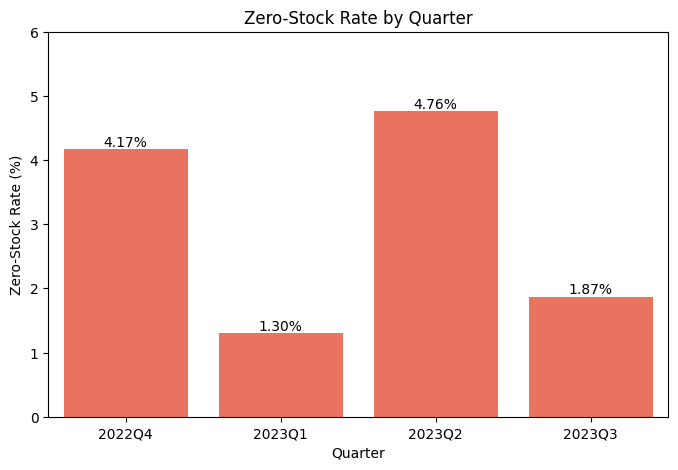

In [ ]:
plt.figure(figsize=(8, 5))

ax = sns.barplot(
    data=quarter_analysis,
    x='Quarter',
    y='zero_stock_rate_pct',
    color='tomato'
)

ax.bar_label(
    ax.containers[0],
    fmt='%.2f%%'
)

plt.title('Zero-Stock Rate by Quarter')
plt.xlabel('Quarter')
plt.ylabel('Zero-Stock Rate (%)')
plt.ylim(0, 6)
plt.show()

**Finding:** The highest zero-stock rate occurred in 2023Q2 at 4.76%, while the lowest rate occurred in 2023Q1 at 1.30%.

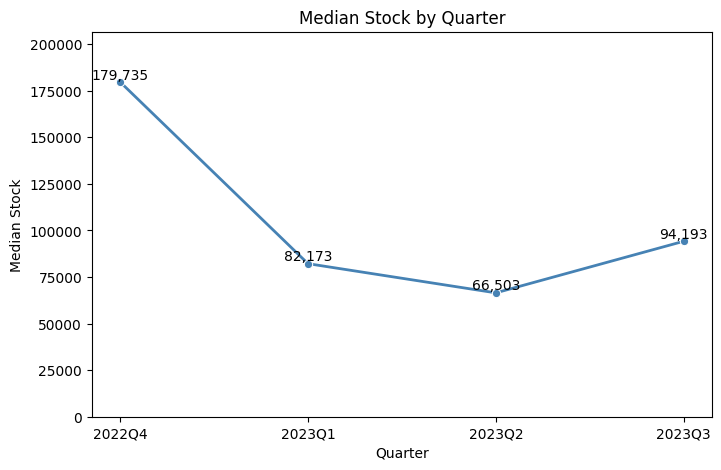

In [ ]:
plt.figure(figsize=(8, 5))

ax = sns.lineplot(
    data=quarter_analysis,
    x='Quarter',
    y='median_stock',
    marker='o',
    color='steelblue',
    linewidth=2
)

for i, value in enumerate(quarter_analysis['median_stock']):
    ax.text(
        i,
        value,
        f'{value:,.0f}',
        ha='center',
        va='bottom'
    )

plt.title('Median Stock by Quarter')
plt.xlabel('Quarter')
plt.ylabel('Median Stock')
plt.ylim(0, quarter_analysis['median_stock'].max() * 1.15)
plt.show()

**Finding:** Median stock declined from 179,735 in 2022Q4 to 66,503 in 2023Q2, before increasing to 94,193 in 2023Q3.

In [ ]:
latest_quarter = s3_clean['Quarter'].max()

latest_stock = s3_clean[
    s3_clean['Quarter'] == latest_quarter
].copy()

top10_latest = latest_stock.nlargest(10, 'Stock')

print("Latest quarter:", latest_quarter)
print("Number of items:", latest_stock['Item'].nunique())

top10_latest[['Item', 'Stock']]

Latest quarter: 2023Q3
Number of items: 107


,Item,Stock
101,"Condom, Male",16574183
242,"Needle, Spinal, 22G",11321463
260,"Paracetamol 250mg, Dispersible, Tab",6927420
12,"Amoxicillin 250mg, Dispersible, Tab",5710781
183,"Ibuprofen 200mg, Tab",4125241
262,"Paracetamol 500mg, Tab",3962723
153,"Glove, Exam, Latex, Medium, Nonsterile, Dispos...",3925608
252,"Oral Rehydration Salts (ORS), Sachet",3487638
136,"Folic Acid 5mg, Tab",2616322
115,"Envelope, Dispensing, Plastic, 10cm x 7cm, Pcs",2343443


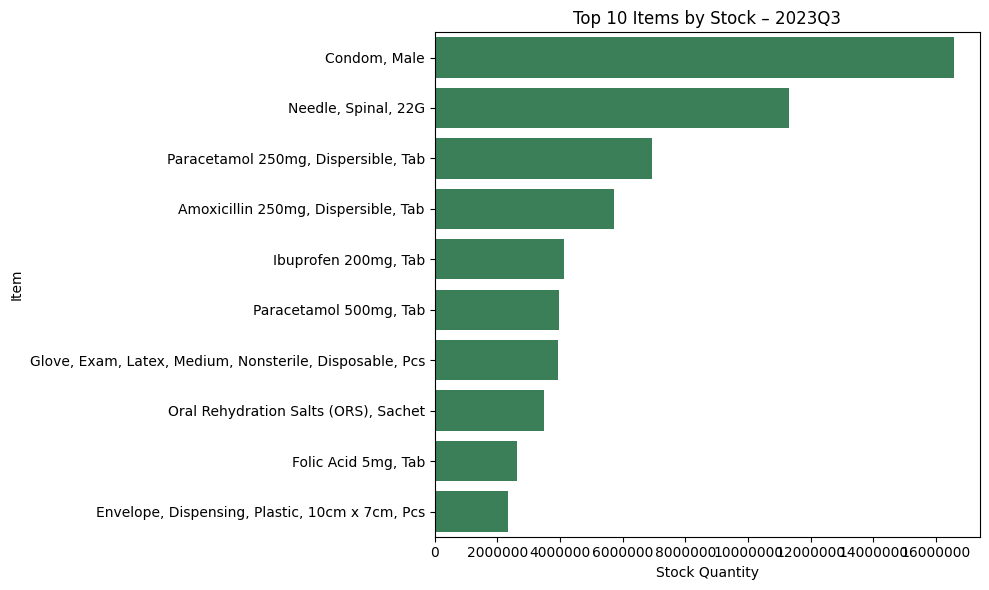

In [ ]:
plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=top10_latest,
    x='Stock',
    y='Item',
    color='seagreen'
)

ax.ticklabel_format(style='plain', axis='x')

plt.title(f'Top 10 Items by Stock – {latest_quarter}')
plt.xlabel('Stock Quantity')
plt.ylabel('Item')
plt.tight_layout()
plt.show()

**Finding:** Condom, Male recorded the highest stock in 2023Q3 with 16,574,183 units, followed by Needle, Spinal, 22G with 11,321,463 units. High stock alone does not confirm surplus without demand or consumption data.

In [ ]:
q1 = s3_clean['Stock'].quantile(0.25)
q3 = s3_clean['Stock'].quantile(0.75)

iqr = q3 - q1
upper_bound = q3 + (1.5 * iqr)

outliers = s3_clean[
    s3_clean['Stock'] > upper_bound
]

print("Q1:", q1)
print("Q3:", q3)
print("Upper bound:", upper_bound)
print("Number of high outliers:", len(outliers))

outliers.nlargest(10, 'Stock')

Q1: 14059.0
Q3: 587856.75
Upper bound: 1448553.375
Number of high outliers: 49


,Item,Stock,Quarter
129,Ferrous Sulphate & Folic Acid (FeFol) 200mg & ...,64239779,2022Q4
128,Ferrous Sulphate & Folic Acid (FeFol) 200mg & ...,23438648,2023Q1
217,"Metronidazole 250mg, Tab",18422508,2022Q4
101,"Condom, Male",16574183,2023Q3
258,"Paracetamol (Acetaminophen) 250mg, Dispersible...",14296563,2022Q4
135,"Folic Acid 5mg, Tab",13767675,2022Q4
242,"Needle, Spinal, 22G",11321463,2023Q3
100,"Condom, Male",9423821,2022Q4
338,"Zinc Sulphate 20mg, Dispersible, Tab",9153894,2022Q4
257,"Paracetamol (Acetaminophen) 250mg, Dispersible...",8187500,2023Q1


**Finding:** The stock distribution contains 49 high-value outliers above 1,448,553 units. These records were retained because they may represent valid high-volume medical supplies.

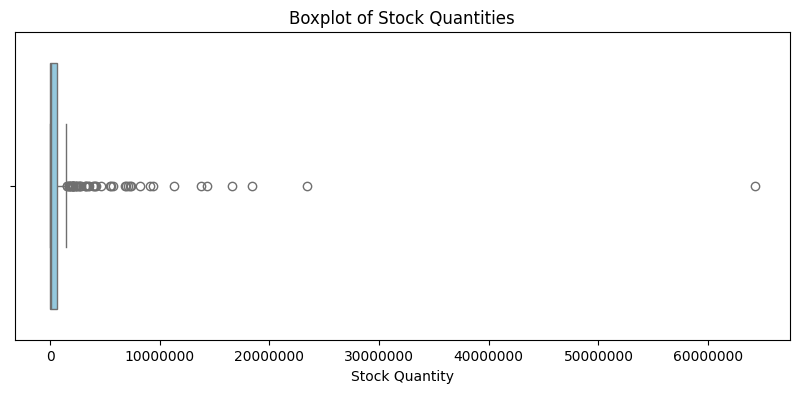

In [ ]:
plt.figure(figsize=(10, 4))

ax = sns.boxplot(
    x=s3_clean['Stock'],
    color='skyblue'
)

ax.ticklabel_format(style='plain', axis='x')

plt.title('Boxplot of Stock Quantities')
plt.xlabel('Stock Quantity')
plt.show()

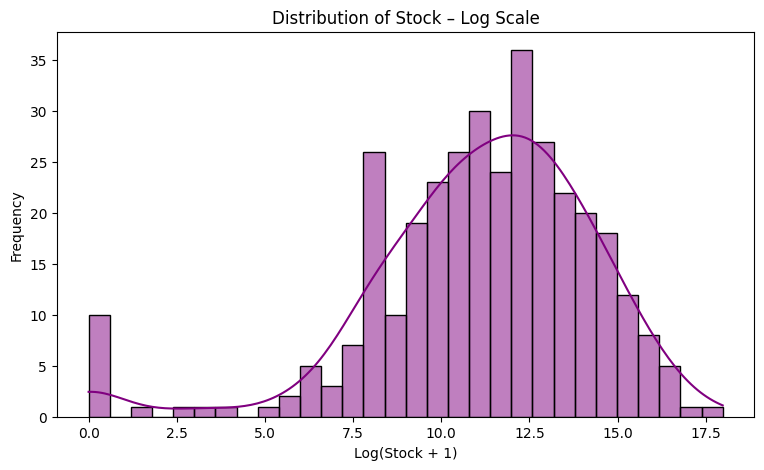

In [ ]:
plt.figure(figsize=(9, 5))

sns.histplot(
    np.log1p(s3_clean['Stock']),
    bins=30,
    kde=True,
    color='purple'
)

plt.title('Distribution of Stock – Log Scale')
plt.xlabel('Log(Stock + 1)')
plt.ylabel('Frequency')
plt.show()

In [ ]:
number_of_quarters = s3_clean['Quarter'].nunique()

item_quarter_counts = (
    s3_clean.groupby('Item')['Quarter']
    .nunique()
)

common_items = item_quarter_counts[
    item_quarter_counts == number_of_quarters
].index

common_data = s3_clean[
    s3_clean['Item'].isin(common_items)
].copy()

print("Items appearing in all quarters:", len(common_items))

Items appearing in all quarters: 30


In [ ]:
common_summary = (
    common_data.groupby('Quarter')
    .agg(
        total_stock=('Stock', 'sum'),
        average_stock=('Stock', 'mean'),
        median_stock=('Stock', 'median')
    )
    .reset_index()
)

common_summary

,Quarter,total_stock,average_stock,median_stock
0,2022Q4,53505486,1.783516e+06,516094.5
1,2023Q1,34492094,1.149736e+06,393341.0
2,2023Q2,23957351,7.985784e+05,237557.0
3,2023Q3,35621747,1.187392e+06,321141.0


## S3 EDA Summary

- The dataset contained 341 rows and 3 columns.
- No missing or negative stock values were found.
- One exact duplicated row was identified and removed, leaving 340 records.
- The dataset included 150 unique items across four quarters.
- Ten zero-stock records were identified.
- The highest zero-stock rate occurred in 2023Q2 at 4.76%.
- Stock quantities were strongly right-skewed, with 49 high-value outliers retained for analysis.
- Median stock declined until 2023Q2 and partially recovered in 2023Q3.
- S3 does not contain hospital IDs, locations, consumption, demand, or expiry dates; therefore, it cannot independently identify hospital-level shortages, surplus, or the nearest supplying hospital.

In [ ]:
s1 = pd.read_csv(FILES['S1'])

display(s1.head())
print("Shape:", s1.shape)
print("Columns:", s1.columns.tolist())

s1.info()

,facility_type,hf_pk,district
0,CHC,0,Port Loko
1,CHP,1,Western Rural
2,MCHP,2,Western Rural
3,MCHP,3,Western Rural
4,CHP,4,Western Rural


Shape: (1280, 3)
Columns: ['facility_type', 'hf_pk', 'district']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1280 entries, 0 to 1279
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   facility_type  1280 non-null   object
 1   hf_pk          1280 non-null   int64 
 2   district       1280 non-null   object
dtypes: int64(1), object(2)
memory usage: 30.1+ KB


## 4. Dataset S5 – Population-Based Demand and Allocation

S5 contains population-based demand estimates and allocation decisions for each facility-product combination. It can support the estimation of facility needs and comparison between estimated demand and allocated quantities.

In [ ]:
s5 = pd.read_csv(FILES['S5'])

display(s5.head())

print("Shape:", s5.shape)
print("Columns:", s5.columns.tolist())

s5.info()

,quarterID,hf_pk,productID,name1,Q3AIalloc,popDQ3,Q2AIalloc,popDQ2,ExcelAlloc,popD
0,1,663,1,"Envelope, Dispensing, Plastic, 10cm x 7cm, Pcs",26.0,NaN,NaN,21.100892,NaN,NaN
1,1,667,1,"Envelope, Dispensing, Plastic, 10cm x 7cm, Pcs",47.0,NaN,NaN,56.189831,NaN,NaN
2,1,745,1,"Envelope, Dispensing, Plastic, 10cm x 7cm, Pcs",34.0,NaN,NaN,16.242442,NaN,NaN
3,1,753,1,"Envelope, Dispensing, Plastic, 10cm x 7cm, Pcs",35.0,NaN,NaN,16.242442,NaN,NaN
4,1,725,1,"Envelope, Dispensing, Plastic, 10cm x 7cm, Pcs",31.0,NaN,NaN,13.942039,NaN,NaN


Shape: (229914, 10)
Columns: ['quarterID', 'hf_pk', 'productID', 'name1', 'Q3AIalloc', 'popDQ3', 'Q2AIalloc', 'popDQ2', 'ExcelAlloc', 'popD']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 229914 entries, 0 to 229913
Data columns (total 10 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   quarterID   229914 non-null  int64  
 1   hf_pk       229914 non-null  int64  
 2   productID   229914 non-null  int64  
 3   name1       229914 non-null  object 
 4   Q3AIalloc   187277 non-null  float64
 5   popDQ3      31772 non-null   float64
 6   Q2AIalloc   21135 non-null   float64
 7   popDQ2      180199 non-null  float64
 8   ExcelAlloc  34491 non-null   float64
 9   popD        34166 non-null   float64
dtypes: float64(6), int64(3), object(1)
memory usage: 17.5+ MB


In [ ]:
key_cols = ['quarterID', 'hf_pk', 'productID']

missing_summary = pd.DataFrame({
    'missing_count': s5.isna().sum(),
    'missing_pct': (s5.isna().mean() * 100).round(2)
}).sort_values('missing_pct', ascending=False)

display(missing_summary)

print("Exact duplicated rows:", s5.duplicated().sum())
print(
    "Duplicated facility-product-quarter keys:",
    s5.duplicated(subset=key_cols).sum()
)

print("\nUnique quarters:", s5['quarterID'].nunique())
print("Unique facilities:", s5['hf_pk'].nunique())
print("Unique products:", s5['productID'].nunique())

,missing_count,missing_pct
Q2AIalloc,208779,90.81
popDQ3,198142,86.18
popD,195748,85.14
ExcelAlloc,195423,85.00
popDQ2,49715,21.62
Q3AIalloc,42637,18.54
hf_pk,0,0.00
quarterID,0,0.00
productID,0,0.00
name1,0,0.00


Exact duplicated rows: 1676
Duplicated facility-product-quarter keys: 12584

Unique quarters: 16
Unique facilities: 1092
Unique products: 36


In [ ]:
# Keep the original data unchanged
s5_clean = s5.drop_duplicates().reset_index(drop=True).copy()

repeated_keys = s5_clean[
    s5_clean.duplicated(subset=key_cols, keep=False)
].sort_values(key_cols)

print("Rows before cleaning:", len(s5))
print("Rows after removing exact duplicates:", len(s5_clean))
print("Exact duplicates removed:", len(s5) - len(s5_clean))

print(
    "Remaining duplicated keys:",
    s5_clean.duplicated(subset=key_cols).sum()
)

display(repeated_keys.head(12))

Rows before cleaning: 229914
Rows after removing exact duplicates: 228238
Exact duplicates removed: 1676
Remaining duplicated keys: 10908


,quarterID,hf_pk,productID,name1,Q3AIalloc,popDQ3,Q2AIalloc,popDQ2,ExcelAlloc,popD
1673,1,0,29,"Glucose (Dextrose) Hypertonic 50%, IV Inj, 50m...",NaN,376.0,NaN,75.987695,NaN,NaN
1674,1,0,29,"Glucose (Dextrose) Hypertonic 50%, IV Inj, 50m...",NaN,2922.0,NaN,75.987695,NaN,NaN
1906,1,0,32,"Ampicillin 500mg, Pdr for IM/IV, Inj, Vial",65.0,NaN,NaN,1.266462,NaN,NaN
1907,1,0,32,"Ampicillin 500mg, Pdr for IM/IV, Inj, Vial",81.0,NaN,NaN,1.266462,NaN,NaN
2230,1,0,33,"Cannula, IV, 24G, Short, Sterile, Disposable, Pcs",206.0,NaN,NaN,0.126646,NaN,NaN
2231,1,0,33,"Cannula, IV, 24G, Short, Sterile, Disposable, Pcs",589.0,NaN,NaN,0.126646,NaN,NaN
8970,1,0,34,"Folic Acid 5mg, Tab",1267.0,NaN,NaN,NaN,NaN,NaN
8971,1,0,34,"Folic Acid 5mg, Tab",596.0,NaN,NaN,NaN,NaN,NaN
3137,1,0,35,"Oxytocin 10IU, Inj, Amp",85.0,NaN,NaN,0.126646,NaN,NaN
3138,1,0,35,"Oxytocin 10IU, Inj, Amp",68.0,NaN,NaN,0.126646,NaN,NaN


Finding: After removing 1,676 exact duplicate rows, 10,908 repeated facility-product-quarter keys remained. These records contained different demand or allocation values, so they were retained rather than removed without a documented selection rule.

In [ ]:
value_cols = [
    'Q3AIalloc', 'popDQ3',
    'Q2AIalloc', 'popDQ2',
    'ExcelAlloc', 'popD'
]

records_per_quarter = (
    s5_clean.groupby('quarterID')
    .size()
    .rename('number_of_records')
)

availability_pct = (
    s5_clean.groupby('quarterID')[value_cols]
    .count()
    .div(records_per_quarter, axis=0)
    .mul(100)
    .round(2)
    .add_suffix('_available_pct')
)

availability_by_quarter = pd.concat(
    [records_per_quarter, availability_pct],
    axis=1
)

display(availability_by_quarter)

,number_of_records,Q3AIalloc_available_pct,popDQ3_available_pct,Q2AIalloc_available_pct,popDQ2_available_pct,ExcelAlloc_available_pct,popD_available_pct
quarterID,,,,,,,
1,13650,85.25,11.62,7.42,74.64,0.00,0.00
2,13631,83.24,12.56,8.26,75.53,0.00,0.00
3,13474,81.91,13.07,8.19,76.35,0.00,0.00
4,15895,84.43,11.61,8.02,77.38,0.00,0.00
5,17799,84.80,11.17,8.45,76.55,0.00,0.00
6,15798,83.93,11.75,8.00,77.42,0.00,0.00
7,15572,83.01,12.40,8.26,78.53,0.00,0.00
8,13122,81.23,13.63,7.22,79.71,0.00,0.00
9,13782,80.79,13.63,7.65,79.26,0.00,0.00


In [ ]:
display(
    availability_by_quarter[
        ['ExcelAlloc_available_pct', 'popD_available_pct']
    ]
)

,ExcelAlloc_available_pct,popD_available_pct
quarterID,,
1,0.00,0.00
2,0.00,0.00
3,0.00,0.00
4,0.00,0.00
5,0.00,0.00
6,0.00,0.00
7,0.00,0.00
8,0.00,0.00
9,0.00,0.00


Finding: Missingness was method- and period-specific. Excel-based allocation and population-demand estimates were available only in quarters 12–14, while other methods covered all 16 quarters with varying completeness. Missing values were retained as NaN because they indicate unavailable estimates rather than zero demand.

In [ ]:
available_count = s5_clean[value_cols].notna().sum()

numeric_summary = pd.DataFrame({
    'available_count': available_count,
    'mean': s5_clean[value_cols].mean(),
    'median': s5_clean[value_cols].median(),
    'maximum': s5_clean[value_cols].max(),
    'zero_pct_available': (
        s5_clean[value_cols].eq(0).sum()
        .div(available_count)
        .mul(100)
    ),
    'negative_count': s5_clean[value_cols].lt(0).sum()
}).round(2)

display(numeric_summary)

,available_count,mean,median,maximum,zero_pct_available,negative_count
Q3AIalloc,186785,430.44,169.00,23236.00,0.99,0
popDQ3,30613,407.06,261.00,23294.00,3.69,0
Q2AIalloc,20283,290.50,200.00,4000.00,0.00,0
popDQ2,179016,7.51,0.76,380.73,0.00,0
ExcelAlloc,34268,2460.32,396.74,864382.00,0.00,0
popD,33943,1619.92,468.83,76335.82,0.00,0


Finding: No negative demand or allocation values were found. All numerical variables were strongly right-skewed, with means exceeding medians and very large maximum values. ExcelAlloc showed the most extreme range. High values were retained because they may represent genuine high-demand facilities or products.

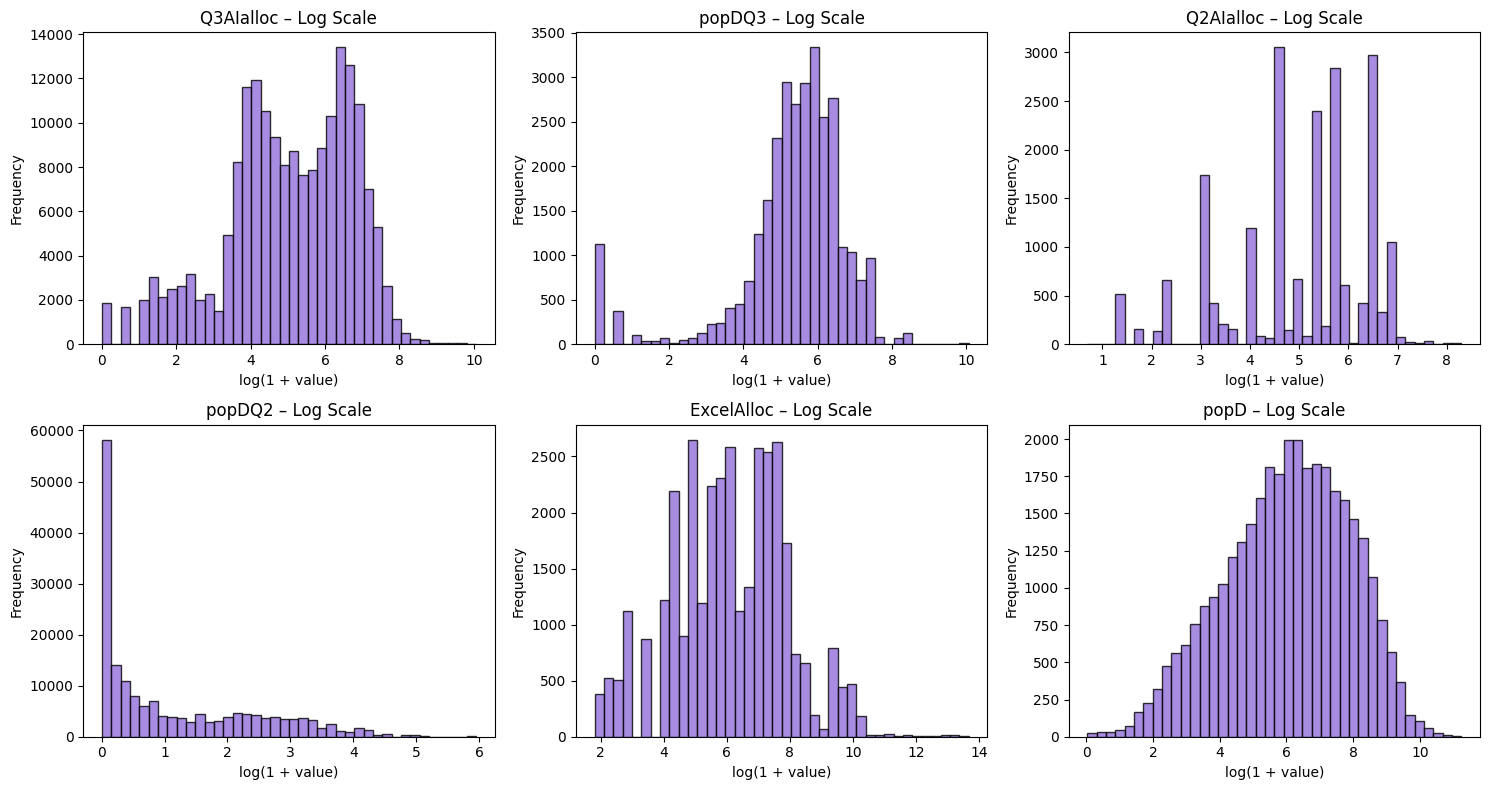

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for col, ax in zip(value_cols, axes.flatten()):
    log_values = np.log1p(s5_clean[col].dropna())

    ax.hist(
        log_values,
        bins=40,
        color='mediumpurple',
        edgecolor='black',
        alpha=0.8
    )

    ax.set_title(f'{col} – Log Scale')
    ax.set_xlabel('log(1 + value)')
    ax.set_ylabel('Frequency')

plt.tight_layout()
plt.show()

Finding: Even after logarithmic transformation, the variables showed different and sometimes multimodal distributions. This indicates method-specific scales and possibly discrete allocation rules; therefore, the allocation and demand columns should be analysed separately.

In [ ]:
comparison_pairs = {
    'Q3 AI vs Population Q3': ('Q3AIalloc', 'popDQ3'),
    'Q2 AI vs Population Q2': ('Q2AIalloc', 'popDQ2'),
    'Excel vs Population': ('ExcelAlloc', 'popD')
}

comparison_results = []

for label, (allocation_col, demand_col) in comparison_pairs.items():
    paired = s5_clean[[allocation_col, demand_col]].dropna()

    result = {
        'comparison': label,
        'matched_records': len(paired)
    }

    if len(paired) > 0:
        gap = paired[allocation_col] - paired[demand_col]

        result.update({
            'allocation_median': paired[allocation_col].median(),
            'demand_median': paired[demand_col].median(),
            'median_gap': gap.median(),
            'allocation_below_demand_pct': (gap < 0).mean() * 100,
            'correlation': paired[allocation_col].corr(paired[demand_col])
        })
    else:
        result.update({
            'allocation_median': np.nan,
            'demand_median': np.nan,
            'median_gap': np.nan,
            'allocation_below_demand_pct': np.nan,
            'correlation': np.nan
        })

    comparison_results.append(result)

comparison_summary = pd.DataFrame(comparison_results).round(2)
display(comparison_summary)

,comparison,matched_records,allocation_median,demand_median,median_gap,allocation_below_demand_pct,correlation
0,Q3 AI vs Population Q3,0,NaN,NaN,NaN,NaN,NaN
1,Q2 AI vs Population Q2,17724,200.00,3.83,195.56,0.51,0.25
2,Excel vs Population,33943,396.74,468.83,-11.54,54.77,0.18


Finding: Q3 AI allocation and Q3 population demand never appeared together, preventing direct comparison. Q2 and Excel comparisons showed weak correlations and substantial differences between allocation and demand estimates. These gaps represent differences between estimation methods and should not be interpreted as confirmed stock shortages.

In [ ]:
popd_key_level = (
    s5_clean
    .dropna(subset=['popD'])
    .groupby(
        ['quarterID', 'hf_pk', 'productID', 'name1'],
        as_index=False
    )
    .agg(popD=('popD', 'median'))
)

product_demand = (
    popd_key_level
    .groupby(['productID', 'name1'], as_index=False)
    .agg(
        available_records=('popD', 'size'),
        facility_count=('hf_pk', 'nunique'),
        total_population_demand=('popD', 'sum'),
        median_population_demand=('popD', 'median')
    )
    .sort_values('total_population_demand', ascending=False)
)

display(product_demand.head(10).round(2))

,productID,name1,available_records,facility_count,total_population_demand,median_population_demand
14,34,"Folic Acid 5mg, Tab",3036,1069,16362660.47,3755.02
19,43,"Zinc Sulphate 20mg, Dispersible, Tab",3057,1073,13396187.94,3101.22
21,46,"Paracetamol (Acetaminophen) 250mg, Dispersible...",2808,1066,11099088.38,2443.03
20,44,"Glove, Exam, Latex, Medium, Nonsterile, Dispos...",2186,947,3611424.94,1127.11
16,38,"Albendazole 400mg, Tab",3145,1075,3091728.65,642.97
18,42,"Methyldopa 250mg, Tab",2879,1065,1907416.70,408.77
12,32,"Ampicillin 500mg, Pdr for IM/IV, Inj, Vial",1483,755,885384.52,428.18
17,39,"Oral Rehydration Salts (ORS), Sachet",2963,1074,698950.36,139.97
23,50,"Paracetamol (Acetaminophen) 500mg, Tab",568,568,345632.39,440.84
15,35,"Oxytocin 10IU, Inj, Amp",2730,1033,344267.31,74.90


Finding: Folic Acid 5mg had the highest estimated population demand at 16.36 million, followed by Zinc Sulphate 20mg at 13.40 million and Paracetamol 250mg at 11.10 million. These estimates are based only on available popD records from quarters 12–14 and represent model-based demand rather than actual consumption.

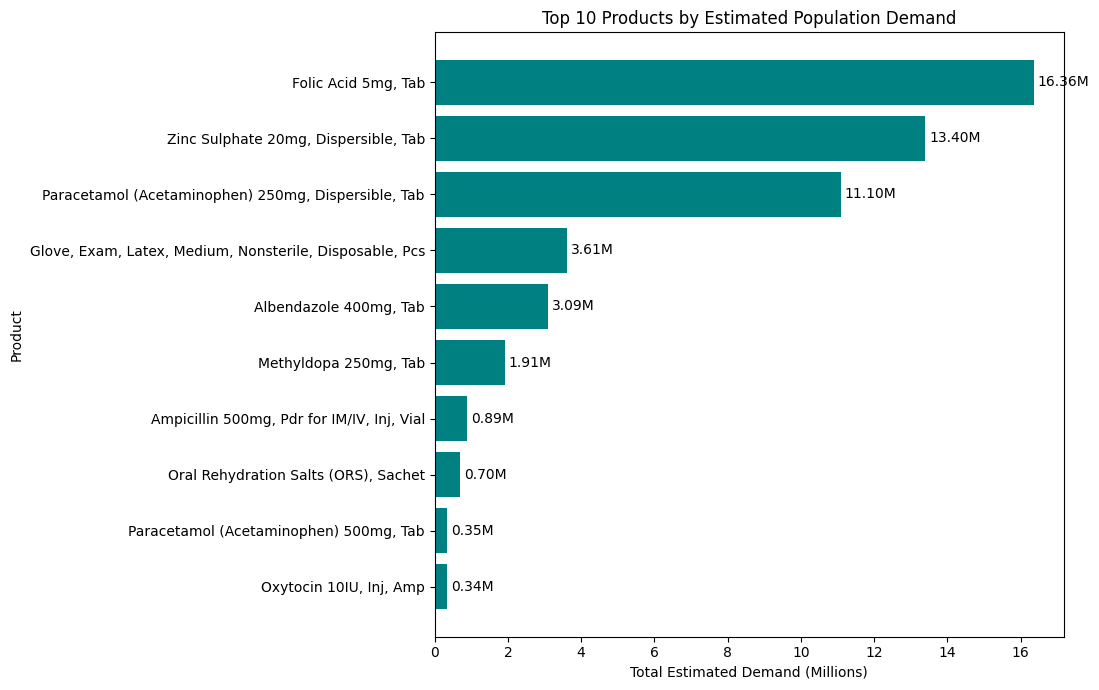

In [ ]:
top10_products = (
    product_demand
    .head(10)
    .sort_values('total_population_demand')
    .copy()
)

top10_products['demand_millions'] = (
    top10_products['total_population_demand'] / 1_000_000
)

plt.figure(figsize=(11, 7))

bars = plt.barh(
    top10_products['name1'],
    top10_products['demand_millions'],
    color='teal'
)

for bar, value in zip(bars, top10_products['demand_millions']):
    plt.text(
        value + 0.1,
        bar.get_y() + bar.get_height() / 2,
        f'{value:.2f}M',
        va='center'
    )

plt.title('Top 10 Products by Estimated Population Demand')
plt.xlabel('Total Estimated Demand (Millions)')
plt.ylabel('Product')
plt.tight_layout()
plt.show()

In [ ]:
facility_demand = (
    popd_key_level
    .groupby('hf_pk', as_index=False)
    .agg(
        available_records=('popD', 'size'),
        product_count=('productID', 'nunique'),
        quarter_count=('quarterID', 'nunique'),
        total_population_demand=('popD', 'sum'),
        median_population_demand=('popD', 'median')
    )
    .sort_values('total_population_demand', ascending=False)
)

display(facility_demand.head(10).round(2))

,hf_pk,available_records,product_count,quarter_count,total_population_demand,median_population_demand
119,167,40,18,3,653352.07,5541.23
23,31,31,14,3,471171.98,5388.60
24,32,24,9,3,448511.84,9033.31
33,53,25,11,3,337519.60,5760.45
944,10127,28,12,3,315757.89,4316.05
269,350,32,16,3,308741.60,2961.72
949,10134,30,13,3,293556.84,3673.57
34,58,19,10,3,289182.67,9006.57
84,127,39,17,3,271358.64,2137.55
21,28,21,11,3,254162.55,4877.97


In [ ]:
total_popd = popd_key_level['popD'].sum()

concentration_summary = pd.DataFrame({
    'dimension': ['Products', 'Facilities'],

    'top_1_share_pct': [
        product_demand.head(1)['total_population_demand'].sum()
        / total_popd * 100,

        facility_demand.head(1)['total_population_demand'].sum()
        / total_popd * 100
    ],

    'top_3_share_pct': [
        product_demand.head(3)['total_population_demand'].sum()
        / total_popd * 100,

        facility_demand.head(3)['total_population_demand'].sum()
        / total_popd * 100
    ],

    'top_10_share_pct': [
        product_demand.head(10)['total_population_demand'].sum()
        / total_popd * 100,

        facility_demand.head(10)['total_population_demand'].sum()
        / total_popd * 100
    ]
}).round(2)

print("Total estimated population demand:", round(total_popd, 2))
display(concentration_summary)

Total estimated population demand: 52877039.63


,dimension,top_1_share_pct,top_3_share_pct,top_10_share_pct
0,Products,30.94,77.27,97.85
1,Facilities,1.24,2.97,6.89


### S5 EDA Summary and Limitations

- The raw dataset contained 229,914 records. After removing 1,676 exact duplicates, 228,238 records remained.
- The dataset covered 16 quarters, 1,092 healthcare facilities, and 36 products.
- A total of 10,908 repeated facility-product-quarter keys remained because some contained different allocation or demand values. They were retained without an official selection rule.
- Missingness was strongly method- and period-specific. In particular, `ExcelAlloc` and `popD` were mainly available during quarters 12–14. Missing values were therefore retained as unavailable estimates rather than replaced with zeros.
- No negative allocation or demand values were found. All numerical variables were strongly right-skewed and contained potentially valid high values.
- Q3 AI allocation could not be compared directly with Q3 population demand because the two variables had no overlapping observations.
- Q2 and Excel-based comparisons showed weak correlations between allocation and population demand, indicating substantial differences between estimation methods.
- Available `popD` records produced a total estimated population demand of approximately 52.88 million units during quarters 12–14.
- Folic Acid 5mg had the highest estimated demand at 16.36 million units, followed by Zinc Sulphate 20mg at 13.40 million and Paracetamol 250mg at 11.10 million.
- Population demand was highly concentrated by product: the top three products represented 77.27% of total estimated demand, and the top ten represented 97.85%.
- Demand was much more geographically dispersed across facilities: the leading facility represented only 1.24% of total demand, while the top ten facilities represented 6.89%.

**Operational interpretation:** Product-level procurement should prioritise the small group of products responsible for most estimated demand. However, distribution planning must still cover a large number of healthcare facilities because demand is not concentrated in only a few facilities.

**Limitations:** The demand variables are model-based estimates rather than observed consumption or confirmed shortages. Coverage differs across methods and periods, units may not be directly comparable, and `popD` is limited mainly to quarters 12–14. S5 also lacks facility type, district, coordinates, inventory balances, batch information, and expiry dates; therefore, it must be linked with other datasets before making transfer or allocation decisions.

## 2. Facility Key Alignment

This section evaluates whether facility identifiers are consistently represented across S1, S2, and S5 before integration.

In [ ]:
s1_facilities = set(s1['hf_pk'].unique())
s2_facilities = set(s2_clean['hf_pk'].unique())
s5_facilities = set(s5_clean['hf_pk'].unique())

facility_alignment = pd.DataFrame({
    'metric': [
        'Facilities in S1',
        'Facilities in S2',
        'Facilities in S5',
        'S2 facilities found in S1',
        'S5 facilities found in S1',
        'Facilities shared by S2 and S5',
        'Facilities shared by S1, S2 and S5',
        'S1 facilities without S2 records',
        'S5 facilities without S2 records'
    ],
    'count': [
        len(s1_facilities),
        len(s2_facilities),
        len(s5_facilities),
        len(s2_facilities & s1_facilities),
        len(s5_facilities & s1_facilities),
        len(s2_facilities & s5_facilities),
        len(s1_facilities & s2_facilities & s5_facilities),
        len(s1_facilities - s2_facilities),
        len(s5_facilities - s2_facilities)
    ]
})

display(facility_alignment)

print(
    "S5 facility IDs not found in S2:",
    sorted(s5_facilities - s2_facilities)
)

print(
    "S2 facility IDs not found in S1:",
    sorted(s2_facilities - s1_facilities)
)

,metric,count
0,Facilities in S1,1280
1,Facilities in S2,1091
2,Facilities in S5,1092
3,S2 facilities found in S1,1091
4,S5 facilities found in S1,1092
5,Facilities shared by S2 and S5,1091
6,"Facilities shared by S1, S2 and S5",1091
7,S1 facilities without S2 records,189
8,S5 facilities without S2 records,1


S5 facility IDs not found in S2: [np.int64(581)]
S2 facility IDs not found in S1: []


**Finding:** Facility identifiers were highly consistent across the datasets. All S2 and S5 facilities were represented in S1, and 1,091 facilities were shared across S1, S2, and S5. One facility (`hf_pk = 581`) appeared in S5 but had no inventory records in S2. Therefore, S2 will be used as the base table and facility metadata will be added using left joins.

In [ ]:
import re

def normalize_product_name(value):
    value = str(value).strip().lower()

    # Remove surrounding brackets
    value = re.sub(r'^[\(\[]|[\)\]]$', '', value)

    # Standardise punctuation and spaces
    value = re.sub(r'[^a-z0-9]+', ' ', value)

    return ' '.join(value.split())


# Unique product tables
s2_products = (
    s2_clean[['productID', 'name1']]
    .drop_duplicates()
)

s5_products = (
    s5_clean[['productID', 'name1']]
    .drop_duplicates()
)

s3_products = (
    s3[['Item']]
    .drop_duplicates()
)

# Check S2 and S5 using productID
s2_s5_product_match = s2_products.merge(
    s5_products,
    on='productID',
    how='outer',
    suffixes=('_s2', '_s5'),
    indicator=True
)

s2_s5_product_match['name_match'] = (
    s2_s5_product_match['name1_s2']
    == s2_s5_product_match['name1_s5']
)

# Create normalised keys for S2 and S3
s2_products['product_key'] = (
    s2_products['name1']
    .apply(normalize_product_name)
)

s3_products['product_key'] = (
    s3_products['Item']
    .apply(normalize_product_name)
)

s2_s3_product_match = s2_products.merge(
    s3_products,
    on='product_key',
    how='left'
)

product_alignment = pd.DataFrame({
    'metric': [
        'Products in S2',
        'Products in S5',
        'Shared product IDs in S2 and S5',
        'Name mismatches between S2 and S5',
        'S2 products matched with S3',
        'S2 products not matched with S3'
    ],
    'count': [
        s2_products['productID'].nunique(),
        s5_products['productID'].nunique(),
        (
            set(s2_products['productID'])
            & set(s5_products['productID'])
        ).__len__(),
        (
            ~s2_s5_product_match['name_match']
            & s2_s5_product_match['_merge'].eq('both')
        ).sum(),
        s2_s3_product_match['Item'].notna().sum(),
        s2_s3_product_match['Item'].isna().sum()
    ]
})

display(product_alignment)

print("Unmatched S2 products in S3:")

display(
    s2_s3_product_match.loc[
        s2_s3_product_match['Item'].isna(),
        ['productID', 'name1']
    ]
)

,metric,count
0,Products in S2,36
1,Products in S5,36
2,Shared product IDs in S2 and S5,36
3,Name mismatches between S2 and S5,0
4,S2 products matched with S3,34
5,S2 products not matched with S3,2


Unmatched S2 products in S3:


,productID,name1
31,50,"Paracetamol (Acetaminophen) 500mg, Tab"
33,52,"Povidone Iodine 10%, Solution, Bot"


In [ ]:
# Reviewed mappings for products with naming differences in S3
manual_product_matches = {
    50: 'Paracetamol 500mg, Tab',
    52: 'Povidone Iodine 10%, Solution, 200ml, Bot'
}

product_crosswalk = s2_s3_product_match[
    ['productID', 'name1', 'Item']
].copy()

product_crosswalk['match_method'] = 'Normalized exact match'

manual_mask = product_crosswalk['Item'].isna()

product_crosswalk.loc[manual_mask, 'Item'] = (
    product_crosswalk.loc[manual_mask, 'productID']
    .map(manual_product_matches)
)

product_crosswalk.loc[
    manual_mask, 'match_method'
] = 'Manual reviewed match'

product_crosswalk = product_crosswalk.rename(
    columns={
        'name1': 's2_s5_name',
        'Item': 's3_item'
    }
)

product_crosswalk['s3_item_exists'] = (
    product_crosswalk['s3_item'].isin(s3_products['Item'])
)

# Validation
assert product_crosswalk['productID'].is_unique
assert product_crosswalk['s3_item_exists'].all()

print(
    "Products mapped:",
    product_crosswalk['s3_item_exists'].sum(),
    "of",
    len(product_crosswalk)
)

print(
    "Unmapped products:",
    (~product_crosswalk['s3_item_exists']).sum()
)

display(
    product_crosswalk[
        product_crosswalk['match_method'] == 'Manual reviewed match'
    ]
)

display(product_crosswalk.sort_values('productID').head())

Products mapped: 36 of 36
Unmapped products: 0


,productID,s2_s5_name,s3_item,match_method,s3_item_exists
31,50,"Paracetamol (Acetaminophen) 500mg, Tab","Paracetamol 500mg, Tab",Manual reviewed match,True
33,52,"Povidone Iodine 10%, Solution, Bot","Povidone Iodine 10%, Solution, 200ml, Bot",Manual reviewed match,True


,productID,s2_s5_name,s3_item,match_method,s3_item_exists
0,1,"Envelope, Dispensing, Plastic, 10cm x 7cm, Pcs","Envelope, Dispensing, Plastic, 10cm x 7cm, Pcs",Normalized exact match,True
1,2,"Syringe, Luer, 20ml, Disposable, Pcs","Syringe, Luer, 20ml, Disposable, Pcs",Normalized exact match,True
2,3,"Syringe, Luer, 10ml, Disposable, Pcs","Syringe, Luer, 10ml, Disposable, Pcs",Normalized exact match,True
3,4,"Syringe, Luer, 2ml, Disposable, Pcs","Syringe, Luer, 2ml, Disposable, Pcs",Normalized exact match,True
4,5,"Apron, Plastic, Disposable, Pcs","Apron, Plastic, Disposable, Pcs",Normalized exact match,True


### Product Key Alignment

Product identifiers and names were fully consistent between S2 and S5. After name normalization, 34 of the 36 S2 products matched S3 automatically.

The remaining two products were found in S3 under slightly different descriptions and were linked using a manually reviewed product crosswalk. Therefore, all 36 S2/S5 products were successfully linked to S3 without modifying the original product names.

In [ ]:
# Temporal alignment audit
# Keep the original datasets unchanged

s2_time = s2_clean.copy()

s2_time['date_parsed'] = pd.to_datetime(
    s2_time['date'],
    format='mixed',
    errors='coerce'
)

s2_time['reported_quarter'] = (
    s2_time['quarter']
    .astype(str)
    .str.strip()
)

s2_time['calendar_quarter'] = (
    s2_time['date_parsed']
    .dt.to_period('Q')
    .astype(str)
)

# List the periods available in each dataset
s2_reported_periods = sorted(
    s2_time['reported_quarter'].dropna().unique()
)

s2_calendar_periods = sorted(
    s2_time['calendar_quarter'].dropna().unique()
)

s3_periods = sorted(
    s3['Quarter'].dropna().astype(str).str.strip().unique()
)

s5_periods = sorted(
    pd.to_numeric(
        s5_clean['quarterID'],
        errors='coerce'
    )
    .dropna()
    .astype(int)
    .unique()
)

period_inventory = pd.DataFrame({
    'dataset_period': [
        'S2 reported quarter',
        'S2 calendar quarter derived from date',
        'S3 Quarter',
        'S5 quarterID'
    ],
    'number_of_periods': [
        len(s2_reported_periods),
        len(s2_calendar_periods),
        len(s3_periods),
        len(s5_periods)
    ],
    'period_values': [
        ', '.join(s2_reported_periods),
        ', '.join(s2_calendar_periods),
        ', '.join(s3_periods),
        ', '.join(map(str, s5_periods))
    ]
})

display(period_inventory)

print(
    "S2 date range:",
    s2_time['date_parsed'].min().date(),
    "to",
    s2_time['date_parsed'].max().date()
)

print(
    "S2 unique monthly dates:",
    s2_time['date_parsed'].nunique()
)

print(
    "Invalid S2 dates:",
    s2_time['date_parsed'].isna().sum()
)

# Compare the supplied S2 quarter with the calendar quarter
s2_quarter_mismatches = s2_time[
    s2_time['date_parsed'].notna()
    & (
        s2_time['reported_quarter']
        != s2_time['calendar_quarter']
    )
].copy()

print(
    "S2 rows with quarter mismatch:",
    len(s2_quarter_mismatches)
)

display(
    s2_quarter_mismatches
    .groupby(
        ['date_parsed', 'reported_quarter', 'calendar_quarter']
    )
    .size()
    .reset_index(name='row_count')
)

,dataset_period,number_of_periods,period_values
0,S2 reported quarter,16,"2019Q4, 2020Q1, 2020Q2, 2020Q3, 2020Q4, 2021Q1..."
1,S2 calendar quarter derived from date,17,"2019Q4, 2020Q1, 2020Q2, 2020Q3, 2020Q4, 2021Q1..."
2,S3 Quarter,4,"2022Q4, 2023Q1, 2023Q2, 2023Q3"
3,S5 quarterID,16,"1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14,..."


S2 date range: 2019-10-01 to 2023-11-01
S2 unique monthly dates: 50
Invalid S2 dates: 0
S2 rows with quarter mismatch: 22450


,date_parsed,reported_quarter,calendar_quarter,row_count
0,2023-10-01,2023Q3,2023Q4,10513
1,2023-11-01,2023Q3,2023Q4,11937


In [ ]:
# Create auditable temporal keys without modifying original columns

s2_aligned = s2_time.copy()

s2_aligned['source_quarter'] = (
    s2_aligned['reported_quarter']
)

s2_aligned['quarter_mismatch_flag'] = (
    s2_aligned['source_quarter']
    != s2_aligned['calendar_quarter']
)

# Order S2 source periods chronologically
source_quarters = sorted(
    s2_aligned['source_quarter'].dropna().unique(),
    key=lambda value: pd.Period(value, freq='Q')
)

s5_quarter_ids = sorted(
    pd.to_numeric(
        s5_clean['quarterID'],
        errors='coerce'
    )
    .dropna()
    .astype(int)
    .unique()
)

assert len(source_quarters) == len(s5_quarter_ids)

# Candidate S5 quarter mapping
s5_quarter_crosswalk = pd.DataFrame({
    'quarterID': s5_quarter_ids,
    'source_quarter': source_quarters,
    'mapping_method': (
        'Sequential mapping validated by facility-product coverage'
    )
})

# Validate using unique facility-product keys in every period
s2_period_counts = (
    s2_aligned[
        ['source_quarter', 'hf_pk', 'productID']
    ]
    .drop_duplicates()
    .groupby('source_quarter')
    .size()
    .reset_index(
        name='s2_unique_facility_product_keys'
    )
)

s5_period_counts = (
    s5_clean[
        ['quarterID', 'hf_pk', 'productID']
    ]
    .drop_duplicates()
    .groupby('quarterID')
    .size()
    .reset_index(
        name='s5_unique_facility_product_keys'
    )
)

temporal_mapping_validation = (
    s5_quarter_crosswalk
    .merge(
        s2_period_counts,
        on='source_quarter',
        how='left'
    )
    .merge(
        s5_period_counts,
        on='quarterID',
        how='left'
    )
)

temporal_mapping_validation['key_count_difference'] = (
    temporal_mapping_validation[
        's5_unique_facility_product_keys'
    ]
    - temporal_mapping_validation[
        's2_unique_facility_product_keys'
    ]
)

mapping_correlation = temporal_mapping_validation[
    [
        's2_unique_facility_product_keys',
        's5_unique_facility_product_keys'
    ]
].corr().iloc[0, 1]

print(
    "Facility-product count correlation:",
    round(mapping_correlation, 6)
)

display(temporal_mapping_validation)

# Apply the reviewed mapping to an analysis copy of S5
s5_aligned = s5_clean.merge(
    s5_quarter_crosswalk[
        ['quarterID', 'source_quarter']
    ],
    on='quarterID',
    how='left',
    validate='many_to_one'
)

assert len(s5_aligned) == len(s5_clean)
assert s5_aligned['source_quarter'].notna().all()

print("S5 rows successfully assigned:", len(s5_aligned))

Facility-product count correlation: 1.0


,quarterID,source_quarter,mapping_method,s2_unique_facility_product_keys,s5_unique_facility_product_keys,key_count_difference
0,1,2019Q4,Sequential mapping validated by facility-produ...,13094,13094,0
1,2,2020Q1,Sequential mapping validated by facility-produ...,13022,13022,0
2,3,2020Q2,Sequential mapping validated by facility-produ...,12835,12835,0
3,4,2020Q3,Sequential mapping validated by facility-produ...,15224,15224,0
4,5,2020Q4,Sequential mapping validated by facility-produ...,17095,17095,0
5,6,2021Q1,Sequential mapping validated by facility-produ...,15139,15139,0
6,7,2021Q2,Sequential mapping validated by facility-produ...,14873,14873,0
7,8,2021Q3,Sequential mapping validated by facility-produ...,12468,12468,0
8,9,2021Q4,Sequential mapping validated by facility-produ...,13110,13111,1
9,10,2022Q1,Sequential mapping validated by facility-produ...,11237,11238,1


S5 rows successfully assigned: 228238


### Temporal Key Alignment

S2 contained 16 source reporting periods from 2019Q4 to 2023Q3, while its calendar dates extended to November 2023. A calendar-quarter audit identified 22,450 records from October and November 2023 that were labelled as 2023Q3 in the source data.

The sequential mapping of S5 `quarterID` values 1–16 to the S2 source quarters was validated using facility-product coverage, producing an approximately perfect correlation of 1.00. All 228,238 S5 records were successfully assigned to a source quarter.

The original source quarter will therefore be retained for integration with S3 and S5, while the calendar quarter derived from the monthly date will be retained for chronological splitting and time-based modelling.

In [ ]:
# Audit S5 key duplication before integration

s5_key_cols = [
    'source_quarter',
    'hf_pk',
    'productID'
]

s5_value_cols = [
    'Q3AIalloc',
    'popDQ3',
    'Q2AIalloc',
    'popDQ2',
    'ExcelAlloc',
    'popD'
]

# Number of rows for every facility-product-quarter key
s5_key_sizes = (
    s5_aligned
    .groupby(s5_key_cols, dropna=False)
    .size()
    .rename('rows_per_key')
)

s5_duplicate_groups = s5_key_sizes[
    s5_key_sizes > 1
]

s5_duplicate_rows = s5_aligned.merge(
    s5_duplicate_groups.reset_index(),
    on=s5_key_cols,
    how='inner'
)

print("Total S5 rows:", len(s5_aligned))
print("Unique facility-product-quarter keys:", len(s5_key_sizes))
print("Duplicated key groups:", len(s5_duplicate_groups))

print(
    "Extra rows caused by duplicated keys:",
    len(s5_aligned) - len(s5_key_sizes)
)

print(
    "Maximum rows for one key:",
    s5_key_sizes.max()
)

# Check whether product names disagree within a key
name_conflicts = (
    s5_duplicate_rows
    .groupby(s5_key_cols)['name1']
    .nunique()
    .gt(1)
    .sum()
)

print(
    "Duplicated keys with conflicting product names:",
    name_conflicts
)

# Inspect conflicting and repeated values
duplicate_value_profile = []

duplicate_grouped = s5_duplicate_rows.groupby(
    s5_key_cols,
    dropna=False
)

for column in s5_value_cols:

    distinct_count = duplicate_grouped[column].nunique(
        dropna=True
    )

    non_null_count = duplicate_grouped[column].count()

    duplicate_value_profile.append({
        'column': column,

        'groups_with_different_values':
            (distinct_count > 1).sum(),

        'groups_with_same_repeated_value':
            (
                (distinct_count == 1)
                & (non_null_count > 1)
            ).sum(),

        'groups_all_missing':
            (non_null_count == 0).sum()
    })

duplicate_value_profile = pd.DataFrame(
    duplicate_value_profile
)

display(duplicate_value_profile)

# Products responsible for most duplicated keys
product_names = (
    s5_aligned[
        ['productID', 'name1']
    ]
    .drop_duplicates('productID')
)

duplicate_product_summary = (
    s5_duplicate_groups
    .reset_index()
    .groupby('productID')
    .size()
    .reset_index(name='duplicated_key_groups')
    .merge(
        product_names,
        on='productID',
        how='left'
    )
    .sort_values(
        'duplicated_key_groups',
        ascending=False
    )
)

display(duplicate_product_summary.head(10))

# Display example duplicated records
display(
    s5_duplicate_rows[
        s5_key_cols
        + ['name1']
        + s5_value_cols
        + ['rows_per_key']
    ]
    .sort_values(s5_key_cols)
    .head(20)
)

Total S5 rows: 228238
Unique facility-product-quarter keys: 217330
Duplicated key groups: 10908
Extra rows caused by duplicated keys: 10908
Maximum rows for one key: 2
Duplicated keys with conflicting product names: 0


,column,groups_with_different_values,groups_with_same_repeated_value,groups_all_missing
0,Q3AIalloc,155,0,10753
1,popDQ3,10753,0,155
2,Q2AIalloc,0,2901,8007
3,popDQ2,0,10531,377
4,ExcelAlloc,0,2020,8888
5,popD,0,2017,8891


,productID,duplicated_key_groups,name1
11,38,9389,"Albendazole 400mg, Tab"
22,56,430,"Glucose (Dextrose) 5%, IV Inj, 500ml, Soft Bag"
21,54,335,"Misoprostol 200mcg, Tab"
4,24,202,"Erythromycin 125mg/5ml, Pdr for Susp, 100ml, Bot"
1,17,126,"Metoclopramide HCl 10mg, Tab"
6,29,114,"Glucose (Dextrose) Hypertonic 50%, IV Inj, 50m..."
2,18,82,"Prednisolone 5mg, Tab"
0,16,51,"Aluminium Hydroxide 500mg, Tab"
5,28,24,"Benzyl Benzoate 25%, Emulsion, 100ml, Bot"
12,39,16,"Oral Rehydration Salts (ORS), Sachet"


,source_quarter,hf_pk,productID,name1,Q3AIalloc,popDQ3,Q2AIalloc,popDQ2,ExcelAlloc,popD,rows_per_key
90,2019Q4,0,29,"Glucose (Dextrose) Hypertonic 50%, IV Inj, 50m...",NaN,376.0,NaN,75.987695,NaN,NaN,2
91,2019Q4,0,29,"Glucose (Dextrose) Hypertonic 50%, IV Inj, 50m...",NaN,2922.0,NaN,75.987695,NaN,NaN,2
92,2019Q4,0,32,"Ampicillin 500mg, Pdr for IM/IV, Inj, Vial",65.0,NaN,NaN,1.266462,NaN,NaN,2
93,2019Q4,0,32,"Ampicillin 500mg, Pdr for IM/IV, Inj, Vial",81.0,NaN,NaN,1.266462,NaN,NaN,2
94,2019Q4,0,33,"Cannula, IV, 24G, Short, Sterile, Disposable, Pcs",206.0,NaN,NaN,0.126646,NaN,NaN,2
95,2019Q4,0,33,"Cannula, IV, 24G, Short, Sterile, Disposable, Pcs",589.0,NaN,NaN,0.126646,NaN,NaN,2
686,2019Q4,0,34,"Folic Acid 5mg, Tab",1267.0,NaN,NaN,NaN,NaN,NaN,2
687,2019Q4,0,34,"Folic Acid 5mg, Tab",596.0,NaN,NaN,NaN,NaN,NaN,2
96,2019Q4,0,35,"Oxytocin 10IU, Inj, Amp",85.0,NaN,NaN,0.126646,NaN,NaN,2
97,2019Q4,0,35,"Oxytocin 10IU, Inj, Amp",68.0,NaN,NaN,0.126646,NaN,NaN,2


### S5 Duplicate-Key Resolution

S5 contained 10,908 duplicated facility-product-quarter keys, with exactly two rows per duplicated key. Product names were consistent across all duplicated records.

The duplicated rows contained two distinct Q3 values: 10,753 groups differed in population-based Q3 demand and 155 groups differed in Q3 AI allocation. In contrast, Q2 allocation, Q2 population demand, Excel allocation, and baseline population demand were either identical across the two rows or missing.

Based on this structure, the distinct Q3 values were treated as within-quarter components and summed. Repeated Q2 and baseline values were retained once to prevent double-counting. The original S5 data remained unchanged, and the consolidation was performed in a separate analysis table.

In [ ]:
# Consolidate S5 to one row per facility-product-quarter

import numpy as np

# Confirm that contextual values do not conflict
context_columns = [
    'Q2AIalloc',
    'popDQ2',
    'ExcelAlloc',
    'popD'
]

context_conflicts = duplicate_value_profile[
    duplicate_value_profile['column'].isin(context_columns)
]['groups_with_different_values'].sum()

assert context_conflicts == 0

# Confirm that duplicated Q3 values are not identical copies
q3_columns = [
    'Q3AIalloc',
    'popDQ3'
]

repeated_q3_values = duplicate_value_profile[
    duplicate_value_profile['column'].isin(q3_columns)
]['groups_with_same_repeated_value'].sum()

assert repeated_q3_values == 0

# Group at the required integration level
s5_grouped = s5_aligned.groupby(
    s5_key_cols,
    dropna=False,
    sort=False
)

# Keep one copy of identical contextual values
s5_context = s5_grouped[
    [
        'quarterID',
        'name1',
        'Q2AIalloc',
        'popDQ2',
        'ExcelAlloc',
        'popD'
    ]
].first()

# Sum the distinct within-quarter Q3 components
s5_q3_totals = s5_grouped[
    [
        'Q3AIalloc',
        'popDQ3'
    ]
].sum(min_count=1)

# Preserve the number of source rows for auditing
s5_source_counts = s5_grouped.size().rename(
    'source_row_count'
)

s5_ready = (
    s5_context
    .join(s5_q3_totals)
    .join(s5_source_counts)
    .reset_index()
)

s5_ready['aggregation_flag'] = (
    s5_ready['source_row_count']
    .map({
        1: 'Single source row',
        2: 'Two Q3 components summed'
    })
)

s5_ready = s5_ready[
    [
        'source_quarter',
        'quarterID',
        'hf_pk',
        'productID',
        'name1',
        'Q3AIalloc',
        'popDQ3',
        'Q2AIalloc',
        'popDQ2',
        'ExcelAlloc',
        'popD',
        'source_row_count',
        'aggregation_flag'
    ]
]

# Validation
duplicate_keys_after = s5_ready.duplicated(
    s5_key_cols
).sum()

print("S5 rows before consolidation:", len(s5_aligned))
print("S5 rows after consolidation:", len(s5_ready))

print(
    "Rows consolidated:",
    len(s5_aligned) - len(s5_ready)
)

print(
    "Duplicate keys after consolidation:",
    duplicate_keys_after
)

print(
    "Source rows reconciled:",
    s5_ready['source_row_count'].sum()
    == len(s5_aligned)
)

assert len(s5_ready) == 217330
assert duplicate_keys_after == 0
assert s5_ready['source_row_count'].sum() == len(s5_aligned)

# Ensure Q3 totals were preserved
q3_total_validation = pd.DataFrame({
    'column': q3_columns,

    'total_before': [
        s5_aligned[column].sum()
        for column in q3_columns
    ],

    'total_after': [
        s5_ready[column].sum()
        for column in q3_columns
    ]
})

q3_total_validation['difference'] = (
    q3_total_validation['total_after']
    - q3_total_validation['total_before']
)

display(q3_total_validation)

assert np.allclose(
    q3_total_validation['total_before'],
    q3_total_validation['total_after']
)

display(
    s5_ready[
        s5_ready['source_row_count'] == 2
    ].head()
)

S5 rows before consolidation: 228238
S5 rows after consolidation: 217330
Rows consolidated: 10908
Duplicate keys after consolidation: 0
Source rows reconciled: True


,column,total_before,total_after,difference
0,Q3AIalloc,80399539.0,80399539.0,0.0
1,popDQ3,12461478.0,12461478.0,0.0


,source_quarter,quarterID,hf_pk,productID,name1,Q3AIalloc,popDQ3,Q2AIalloc,popDQ2,ExcelAlloc,popD,source_row_count,aggregation_flag
954,2019Q4,1,195,16,"Aluminium Hydroxide 500mg, Tab",NaN,33.0,NaN,8.940884,NaN,NaN,2,Two Q3 components summed
958,2019Q4,1,38,16,"Aluminium Hydroxide 500mg, Tab",NaN,25.0,NaN,5.805376,NaN,NaN,2,Two Q3 components summed
967,2019Q4,1,10292,17,"Metoclopramide HCl 10mg, Tab",NaN,80.0,NaN,3.988965,NaN,NaN,2,Two Q3 components summed
971,2019Q4,1,232,17,"Metoclopramide HCl 10mg, Tab",NaN,353.0,NaN,22.683702,NaN,NaN,2,Two Q3 components summed
972,2019Q4,1,10320,17,"Metoclopramide HCl 10mg, Tab",NaN,258.0,NaN,18.206652,NaN,NaN,2,Two Q3 components summed


In [ ]:
# Audit S1–S2 facility metadata before final integration

def first_non_null(series):
    values = series.dropna()
    return values.iloc[0] if not values.empty else pd.NA


def normalize_text(series):
    return (
        series.astype("string")
        .str.strip()
        .str.casefold()
        .fillna("<missing>")
    )


# S1: canonical facility dimension
s1_facility = (
    s1[
        ["hf_pk", "facility_type", "district"]
    ]
    .drop_duplicates()
    .rename(
        columns={
            "facility_type": "s1_facility_type",
            "district": "s1_district"
        }
    )
)

assert s1_facility["hf_pk"].is_unique


# S2: one metadata profile per facility
s2_facility = (
    s2_aligned
    .groupby("hf_pk", as_index=False)
    .agg(
        s2_facility_type=("facility_type", first_non_null),
        s2_district=("district", first_non_null),
        latitude=("lat", "median"),
        longitude=("long", "median"),
        facility_type_values=("facility_type", "nunique"),
        district_values=("district", "nunique"),
        latitude_values=("lat", "nunique"),
        longitude_values=("long", "nunique")
    )
)


# Compare S1 with S2
facility_metadata_audit = s2_facility.merge(
    s1_facility,
    on="hf_pk",
    how="left",
    validate="one_to_one",
    indicator=True
)

facility_metadata_audit["facility_type_match"] = (
    normalize_text(facility_metadata_audit["s2_facility_type"])
    == normalize_text(facility_metadata_audit["s1_facility_type"])
)

facility_metadata_audit["district_match"] = (
    normalize_text(facility_metadata_audit["s2_district"])
    == normalize_text(facility_metadata_audit["s1_district"])
)


metadata_audit_summary = pd.DataFrame({
    "check": [
        "S1 duplicate facility keys",
        "S2 facilities with multiple facility types",
        "S2 facilities with multiple districts",
        "S2 facilities with multiple coordinates",
        "S2 facilities missing from S1",
        "Facility-type mismatches",
        "District mismatches"
    ],
    "count": [
        int(s1_facility["hf_pk"].duplicated().sum()),
        int((s2_facility["facility_type_values"] > 1).sum()),
        int((s2_facility["district_values"] > 1).sum()),
        int(
            (
                (s2_facility["latitude_values"] > 1)
                | (s2_facility["longitude_values"] > 1)
            ).sum()
        ),
        int((facility_metadata_audit["_merge"] != "both").sum()),
        int((~facility_metadata_audit["facility_type_match"]).sum()),
        int((~facility_metadata_audit["district_match"]).sum())
    ]
})

display(metadata_audit_summary)

metadata_issues = facility_metadata_audit.loc[
    (facility_metadata_audit["_merge"] != "both")
    | (~facility_metadata_audit["facility_type_match"])
    | (~facility_metadata_audit["district_match"])
]

print("S2 facilities audited:", len(facility_metadata_audit))
print("Metadata issues:", len(metadata_issues))

display(metadata_issues.head(20))

,check,count
0,S1 duplicate facility keys,0
1,S2 facilities with multiple facility types,0
2,S2 facilities with multiple districts,0
3,S2 facilities with multiple coordinates,0
4,S2 facilities missing from S1,0
5,Facility-type mismatches,0
6,District mismatches,0


S2 facilities audited: 1091
Metadata issues: 0


,hf_pk,s2_facility_type,s2_district,latitude,longitude,facility_type_values,district_values,latitude_values,longitude_values,s1_facility_type,s1_district,_merge,facility_type_match,district_match


### Final Integration of S1, S2, S3, and S5

S2 is used as the monthly backbone of the integrated dataset. S1 supplies
the canonical facility attributes, S5 supplies population-based demand and
allocation variables, and S3 supplies national stock where the corresponding
product-quarter record is available.

In [ ]:
# Final integration of S1, S2, S3, and consolidated S5

integration_keys = ["hf_pk", "productID", "source_quarter"]
base_rows = len(s2_aligned)


# ---------------------------------------------------------
# 1. Add canonical facility metadata from S1
# ---------------------------------------------------------

facility_dimension = (
    s1_facility[
        ["hf_pk", "s1_facility_type", "s1_district"]
    ]
    .rename(columns={
        "s1_facility_type": "facility_type",
        "s1_district": "district"
    })
)

assert facility_dimension["hf_pk"].is_unique


integrated_data = (
    s2_aligned
    .drop(columns=["facility_type", "district"], errors="ignore")
    .merge(
        facility_dimension,
        on="hf_pk",
        how="left",
        validate="many_to_one",
        indicator="_s1_merge"
    )
)


# ---------------------------------------------------------
# 2. Add population demand and allocation features from S5
# ---------------------------------------------------------

s5_feature_columns = [
    "hf_pk",
    "productID",
    "source_quarter",
    "quarterID",
    "Q3AIalloc",
    "popDQ3",
    "Q2AIalloc",
    "popDQ2",
    "ExcelAlloc",
    "popD",
    "source_row_count"
]

s5_feature_columns = [
    column
    for column in s5_feature_columns
    if column in s5_ready.columns
]


s5_features = (
    s5_ready[s5_feature_columns]
    .rename(columns={
        "quarterID": "s5_quarterID",
        "Q3AIalloc": "s5_Q3AIalloc",
        "popDQ3": "s5_popDQ3",
        "Q2AIalloc": "s5_Q2AIalloc",
        "popDQ2": "s5_popDQ2",
        "ExcelAlloc": "s5_ExcelAlloc",
        "popD": "s5_popD",
        "source_row_count": "s5_source_row_count"
    })
)

assert not s5_features.duplicated(integration_keys).any()


integrated_data = integrated_data.merge(
    s5_features,
    on=integration_keys,
    how="left",
    validate="many_to_one",
    indicator="_s5_merge"
)


# ---------------------------------------------------------
# 3. Prepare and add national stock from S3
# ---------------------------------------------------------

s3_ready = (
    s3
    .drop_duplicates()
    .rename(columns={
        "Item": "s3_item",
        "Stock": "s3_national_stock",
        "Quarter": "source_quarter"
    })[
        ["s3_item", "source_quarter", "s3_national_stock"]
    ]
)

s3_ready["source_quarter"] = (
    s3_ready["source_quarter"]
    .astype("string")
    .str.strip()
)

assert not s3_ready.duplicated(
    ["s3_item", "source_quarter"]
).any()

assert product_crosswalk["productID"].is_unique
assert product_crosswalk["s3_item"].notna().all()


s3_features = (
    product_crosswalk[
        ["productID", "s3_item"]
    ]
    .merge(
        s3_ready,
        on="s3_item",
        how="inner",
        validate="one_to_many"
    )
)

assert not s3_features.duplicated(
    ["productID", "source_quarter"]
).any()


integrated_data = integrated_data.merge(
    s3_features,
    on=["productID", "source_quarter"],
    how="left",
    validate="many_to_one",
    indicator="_s3_merge"
)


# ---------------------------------------------------------
# 4. Create source-availability indicators
# ---------------------------------------------------------

integrated_data["s1_available"] = (
    integrated_data["_s1_merge"] == "both"
)

integrated_data["s5_available"] = (
    integrated_data["_s5_merge"] == "both"
)

integrated_data["s3_available"] = (
    integrated_data["_s3_merge"] == "both"
)


# ---------------------------------------------------------
# 5. Integration integrity tests
# ---------------------------------------------------------

assert len(integrated_data) == base_rows

assert not integrated_data.duplicated(
    ["hf_pk", "productID", "date_parsed"]
).any()


integration_summary = pd.DataFrame({
    "source": [
        "S1 facility metadata",
        "S5 population demand/allocation",
        "S3 national stock"
    ],
    "matched_rows": [
        int(integrated_data["s1_available"].sum()),
        int(integrated_data["s5_available"].sum()),
        int(integrated_data["s3_available"].sum())
    ],
    "coverage_pct": [
        integrated_data["s1_available"].mean() * 100,
        integrated_data["s5_available"].mean() * 100,
        integrated_data["s3_available"].mean() * 100
    ]
}).round(2)


# Remove temporary merge indicators
integrated_data = integrated_data.drop(
    columns=["_s1_merge", "_s5_merge", "_s3_merge"]
)


print("S2 rows before integration:", base_rows)
print("Integrated rows:", len(integrated_data))
print(
    "Duplicate monthly facility-product keys:",
    integrated_data.duplicated(
        ["hf_pk", "productID", "date_parsed"]
    ).sum()
)

display(integration_summary)
display(integrated_data.head())

S2 rows before integration: 457225
Integrated rows: 457225
Duplicate monthly facility-product keys: 0


,source,matched_rows,coverage_pct
0,S1 facility metadata,457225,100.00
1,S5 population demand/allocation,457225,100.00
2,S3 national stock,126166,27.59


,hf_pk,name1,date,stockout,received,consumption,closeBalance,openBalance,lat,long,...,s5_Q2AIalloc,s5_popDQ2,s5_ExcelAlloc,s5_popD,s5_source_row_count,s3_item,s3_national_stock,s1_available,s5_available,s3_available
0,663,"Envelope, Dispensing, Plastic, 10cm x 7cm, Pcs",2019-10-01,0,0,59,0,59,9.089409,-12.00467,...,NaN,21.100892,NaN,NaN,1,NaN,NaN,True,True,False
1,667,"Envelope, Dispensing, Plastic, 10cm x 7cm, Pcs",2019-10-01,0,0,70,0,70,8.903324,-12.04545,...,NaN,56.189831,NaN,NaN,1,NaN,NaN,True,True,False
2,745,"Envelope, Dispensing, Plastic, 10cm x 7cm, Pcs",2019-10-01,1,0,14,0,14,8.807020,-12.08181,...,NaN,16.242442,NaN,NaN,1,NaN,NaN,True,True,False
3,753,"Envelope, Dispensing, Plastic, 10cm x 7cm, Pcs",2019-10-01,0,0,100,0,100,8.791610,-12.06068,...,NaN,16.242442,NaN,NaN,1,NaN,NaN,True,True,False
4,725,"Envelope, Dispensing, Plastic, 10cm x 7cm, Pcs",2019-10-01,0,0,100,0,100,9.032880,-12.04858,...,NaN,13.942039,NaN,NaN,1,NaN,NaN,True,True,False


### EDA Conclusion

The individual and cross-dataset exploratory analyses were completed.
S1, S2, S3, and S5 were aligned using validated facility, product, and
temporal keys. The final integrated dataset contains 457,225 monthly
facility-product records with no duplicated modeling keys.

## Save Final Cleaned & Integrated Dataset

This saves the final `integrated_data` dataframe produced by the EDA/integration workflow to Google Drive so the modeling notebook can load the cleaned integrated data directly without rebuilding the joins.


In [ ]:
FINAL_DATA_PATH = BASE_PATH / 'Madad_Integrated_Data.csv'

if 'integrated_data' not in globals():
    raise NameError("`integrated_data` was not found. Run all previous EDA/integration cells first.")

integrated_data.to_csv(FINAL_DATA_PATH, index=False)

print("Saved successfully!")
print("Path:", FINAL_DATA_PATH)
print("Shape:", integrated_data.shape)
print("File exists:", FINAL_DATA_PATH.exists())

Saved successfully!
Path: /content/drive/MyDrive/Madad for Medical Logistics/Dataset/Dryad_Dataset/Madad_Integrated_Data.csv
Shape: (457225, 34)
File exists: True


In [ ]:
# Reload once to verify that the saved file is readable and has the same shape.
_integrated_check = pd.read_csv(FINAL_DATA_PATH)

print("Reloaded shape:", _integrated_check.shape)
print("Same shape as integrated_data:", _integrated_check.shape == integrated_data.shape)

display(_integrated_check.head())

/tmp/ipykernel_1167/3887640898.py:2: DtypeWarning: Columns (29) have mixed types. Specify dtype option on import or set low_memory=False.
  _integrated_check = pd.read_csv(FINAL_DATA_PATH)


Reloaded shape: (457225, 34)
Same shape as integrated_data: True


,hf_pk,name1,date,stockout,received,consumption,closeBalance,openBalance,lat,long,...,s5_Q2AIalloc,s5_popDQ2,s5_ExcelAlloc,s5_popD,s5_source_row_count,s3_item,s3_national_stock,s1_available,s5_available,s3_available
0,663,"Envelope, Dispensing, Plastic, 10cm x 7cm, Pcs",2019-10-01,0,0,59,0,59,9.089409,-12.00467,...,NaN,21.100892,NaN,NaN,1,NaN,NaN,True,True,False
1,667,"Envelope, Dispensing, Plastic, 10cm x 7cm, Pcs",2019-10-01,0,0,70,0,70,8.903324,-12.04545,...,NaN,56.189831,NaN,NaN,1,NaN,NaN,True,True,False
2,745,"Envelope, Dispensing, Plastic, 10cm x 7cm, Pcs",2019-10-01,1,0,14,0,14,8.807020,-12.08181,...,NaN,16.242442,NaN,NaN,1,NaN,NaN,True,True,False
3,753,"Envelope, Dispensing, Plastic, 10cm x 7cm, Pcs",2019-10-01,0,0,100,0,100,8.791610,-12.06068,...,NaN,16.242442,NaN,NaN,1,NaN,NaN,True,True,False
4,725,"Envelope, Dispensing, Plastic, 10cm x 7cm, Pcs",2019-10-01,0,0,100,0,100,9.032880,-12.04858,...,NaN,13.942039,NaN,NaN,1,NaN,NaN,True,True,False
